Abstract - Análisis Estratégico de Alojamientos en Airbnb
El mercado de alquileres temporarios en Nueva York ha experimentado transformaciones significativas en los últimos años. Este proyecto tiene como objetivo identificar los factores clave que influyen en el éxito de los alojamientos publicados en Airbnb, comprendiendo cómo variables como precio, ubicación, tipo de alojamiento y disponibilidad impactan en la rentabilidad y popularidad de los anuncios. Mediante análisis exploratorio de datos (EDA), se busca generar información valiosa para que anfitriones e inversores optimicen sus decisiones en el mercado inmobiliario turístico.
El dataset analizado, Airbnb_Open_Data.csv, contiene inicialmente 102,599 registros de publicaciones activas en Nueva York con información detallada sobre precios, número de reseñas, disponibilidad anual, ubicación geográfica, tipo de alojamiento y características del anfitrión. Tras un riguroso proceso de limpieza que incluyó la eliminación de duplicados (541 registros), valores imposibles (2,953 registros) y filtrado temporal al período 2016-2025 (2,205 registros), se obtuvo un dataset final de 96,900 registros válidos, representando una pérdida justificada del 5.55%.
El análisis se estructuró en torno a cuatro hipótesis principales:

Variación de precios por ubicación y tipo de alojamiento: Se confirmó que el precio promedio varía significativamente según barrio, con diferencias de hasta $184 entre zonas. Manhattan y Brooklyn concentran el 83% de la oferta total, y los alojamientos completos ("Entire home/apt") representan el 52% del mercado.
Relación entre precio y popularidad: Se rechazó la hipótesis de correlación positiva. El análisis reveló una correlación precio-reseñas de apenas 0.005, demostrando que el precio no determina la popularidad. Esto sugiere que factores como ubicación, experiencia del huésped y calidad del servicio son más determinantes.
Impacto de la disponibilidad anual: Se identificó que la disponibilidad promedio es de 133.7 días/año, con patrones diferenciados por barrio y tipo de propiedad, aunque su correlación con precio es débil (r=0.116).
Tendencias temporales (2016-2025): Se detectaron hallazgos críticos: una caída del 13.6% en precios promedio (pico en 2020, luego descenso drástico) y del 33% en calidad percibida (puntuación de reseñas cayó de 3.0 a 2.0), sugiriendo saturación del mercado o cambios estructurales post-pandemia.

El análisis exploratorio incluyó visualizaciones univariadas (distribución de tipos de habitación y precios), bivariadas (precio vs. reseñas, políticas de cancelación por barrio) y análisis temporal multivariado. La matriz de correlación identificó que la relación más fuerte es entre número total de reseñas y reseñas mensuales (r=0.613), mientras que las correlaciones con precio son consistentemente débiles en todas las variables analizadas.
Los hallazgos principales proporcionan insights accionables: (1) la diferenciación de servicio es más efectiva que la competencia por precio, (2) la ubicación geográfica continúa siendo el factor más valorado por los usuarios, (3) mantener flexibilidad en las noches mínimas requeridas (1-3 noches) favorece la obtención de reseñas, y (4) existe una tendencia preocupante de deterioro en métricas clave que requiere análisis adicional antes de realizar nuevas inversiones en el sector.
Este trabajo proporciona una base sólida para la toma de decisiones estratégicas en el mercado de alquileres temporarios de Nueva York, evidenciando que el éxito en Airbnb no depende únicamente del pricing, sino de una combinación de factores donde la experiencia del huésped y la ubicación estratégica son determinantes.

# **Librerias**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import math

# **Parte 1: Exploraición del Dataset de "AirBnB":**

# **1- DataSet**

In [2]:
# --- PASO 1: CARGA DEL DATASET ---

print("="*70)
print(" CARGA DEL DATASET: AIRBNB OPEN DATA ".center(70, "="))
print("="*70)

# URL del dataset en GitHub
url = 'https://raw.githubusercontent.com/IturryCamila/Data-Science-Camila-Iturry/refs/heads/main/Airbnb_Open_Data.csv'

# Cargar el DataFrame
try:
    df = pd.read_csv(url, low_memory=False)
    print("\n✓ Dataset cargado exitosamente desde GitHub")
except Exception as e:
    print(f"\n❌ Error al cargar el dataset: {e}")
    raise

# Información general del dataset
print("\n--- INFORMACIÓN GENERAL ---")
print(f"Registros: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print(f"Tamaño en memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Mostrar estructura detallada
print("\n--- ESTRUCTURA DEL DATASET ---")
df.info()

# Vista previa de los datos
print("\n--- PRIMERAS 5 FILAS ---")
display(df.head())

print("\n" + "="*70)
print(" Dataset listo para inspección ".center(70, "="))
print("="*70)

================ CARGA DEL DATASET: AIRBNB OPEN DATA =================

✓ Dataset cargado exitosamente desde GitHub

--- INFORMACIÓN GENERAL ---
Registros: 102,599
Columnas: 26
Tamaño en memoria: 104.69 MB

--- ESTRUCTURA DEL DATASET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                      

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN



=================== Dataset listo para inspección ====================


# **2- Limpieza de datos y Análisis exploratorio de datos (EDA)**

=========== PASO 2: INSPECCIÓN INICIAL DE CALIDAD DE DATOS ===========

--- 1. ANÁLISIS DE VALORES NULOS (ANTES DE CUALQUIER LIMPIEZA) ---
Total de celdas con valores nulos: 190,769
Porcentaje del dataset: 7.15%

Columnas con valores nulos (ordenadas por % de nulos):
                                 Nulos  Porcentaje
license                         102597      100.00
house_rules                      52131       50.81
last review                      15893       15.49
reviews per month                15879       15.48
country                            532        0.52
availability 365                   448        0.44
minimum nights                     409        0.40
host name                          406        0.40
review rate number                 326        0.32
calculated host listings count     319        0.31
host_identity_verified             289        0.28
service fee                        273        0.27
NAME                               250        0.24
price             

/usr/local/lib/python3.12/dist-packages/missingno/missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(


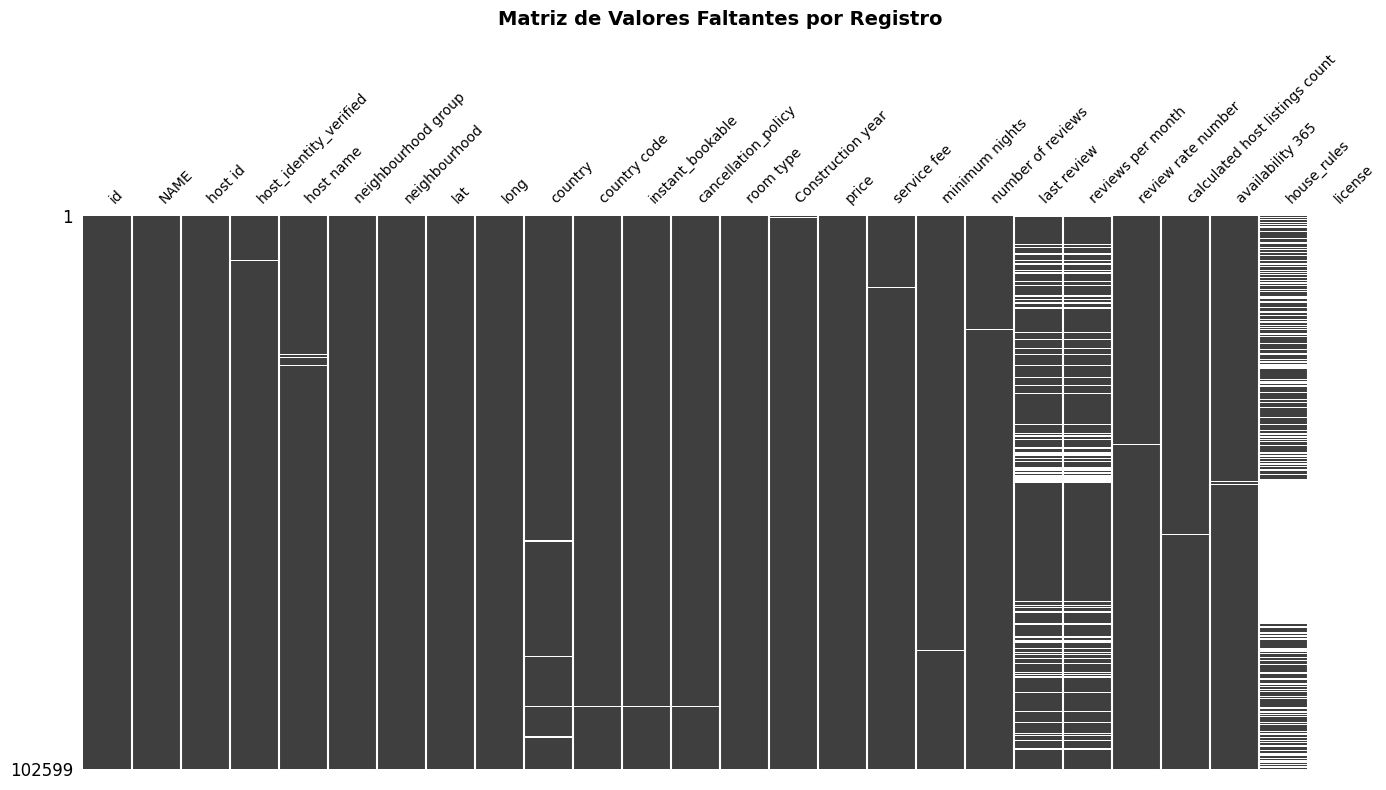


Generando Gráfico de Barras de Completitud...


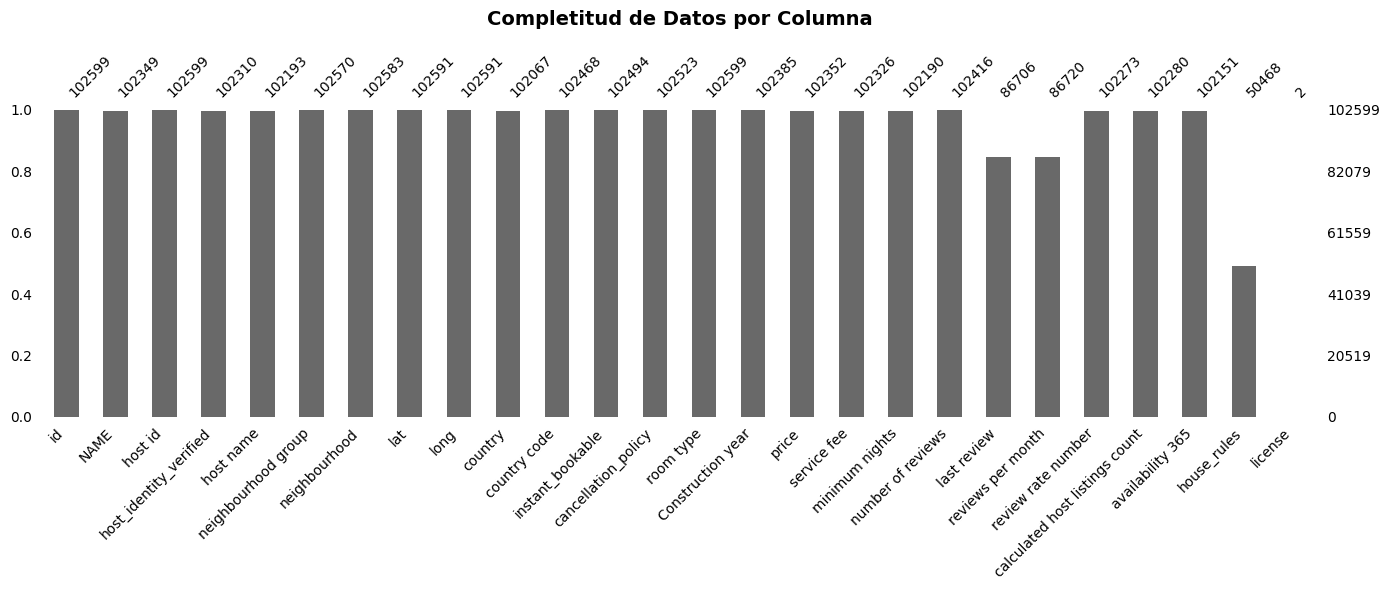


--- 3. ANÁLISIS DE DATOS DUPLICADOS ---
Filas duplicadas encontradas: 541 (0.53%)

🔍 Mostrando las primeras 5 filas duplicadas:


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
102058,35506831,Master Bedroom with private Bathroom & Balcony,55110690425,unconfirmed,UZeyir,Queens,Maspeth,40.74056,-73.90635,United States,...,$141,1.0,1.0,11/14/2021,0.27,3.0,1.0,339.0,NaN,NaN
102059,35507383,Cozy 2 br in sunny Fort Greene apt,80193772189,verified,Sally,Brooklyn,Fort Greene,40.68701,-73.97555,United States,...,$130,3.0,38.0,11/13/2021,0.27,3.0,1.0,0.0,NaN,NaN
102060,35507935,Duplex w/ Terrace @ Box House Hotel,72991962259,verified,The Box House Hotel,Brooklyn,Greenpoint,40.73756,-73.95350,United States,...,$181,3.0,10.0,11/13/2021,0.08,3.0,30.0,32.0,NaN,NaN
102061,35508488,"Cozy, clean Greenpoint room with yard access",74975156081,verified,Dawn,Brooklyn,Greenpoint,40.72516,-73.95004,United States,...,$118,30.0,38.0,11/13/2021,0.34,5.0,2.0,324.0,NaN,NaN
102062,35509040,2BR XL Loft: Cleaning CDC guidelines implemented,85844415221,unconfirmed,Vida,Brooklyn,Greenpoint,40.72732,-73.94185,United States,...,$71,30.0,13.0,11/13/2021,0.14,4.0,28.0,336.0,NaN,NaN



Total de registros involucrados en duplicaciones: 1082

🗑️ Eliminando filas duplicadas...
   ✓ Registros antes: 102,599
   ✓ Registros después: 102,058
   ✓ Registros eliminados: 541
   ✓ Duplicados restantes: 0

--- 4. ELIMINACIÓN DE COLUMNAS IRRELEVANTES ---

🗑️ Columnas con >95% nulos (serán eliminadas):
   • license: 100.0% nulos

✓ 1 columna(s) eliminada(s)

📊 Dimensiones finales del dataset: 102,058 registros × 25 columnas

Columnas restantes:
['id', 'NAME', 'host id', 'host_identity_verified', 'host name', 'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country', 'country code', 'instant_bookable', 'cancellation_policy', 'room type', 'Construction year', 'price', 'service fee', 'minimum nights', 'number of reviews', 'last review', 'reviews per month', 'review rate number', 'calculated host listings count', 'availability 365', 'house_rules']

========== FIN DEL PASO 2: Dataset listo para imputaciones ===========


In [3]:
# --- PASO 2: INSPECCIÓN Y LIMPIEZA INICIAL ---

import missingno as msno
import matplotlib.pyplot as plt

print("="*70)
print(" PASO 2: INSPECCIÓN INICIAL DE CALIDAD DE DATOS ".center(70, "="))
print("="*70)

# ==================== ANÁLISIS DE VALORES NULOS ====================
print("\n--- 1. ANÁLISIS DE VALORES NULOS (ANTES DE CUALQUIER LIMPIEZA) ---")

# 1.1 Conteo y porcentaje de nulos
nulos_totales = df.isna().sum().sum()
print(f"Total de celdas con valores nulos: {nulos_totales:,}")
print(f"Porcentaje del dataset: {100 * nulos_totales / (df.shape[0] * df.shape[1]):.2f}%")

# 1.2 Desglose por columna
print("\nColumnas con valores nulos (ordenadas por % de nulos):")
nulos_por_columna = pd.DataFrame({
    'Nulos': df.isna().sum(),
    'Porcentaje': (df.isna().sum() / df.shape[0] * 100).round(2)
}).sort_values('Porcentaje', ascending=False)

# Mostrar solo columnas con nulos
nulos_por_columna = nulos_por_columna[nulos_por_columna['Nulos'] > 0]
print(nulos_por_columna)

# 1.3 Identificar columnas críticas (>40% nulos)
columnas_criticas = nulos_por_columna[nulos_por_columna['Porcentaje'] > 40]
if len(columnas_criticas) > 0:
    print(f"\n⚠️ COLUMNAS CRÍTICAS (>40% nulos): {list(columnas_criticas.index)}")
    print("   → Considerar eliminar estas columnas del análisis")


# ==================== VISUALIZACIÓN DE NULOS ====================
print("\n--- 2. VISUALIZACIÓN DE PATRONES DE DATOS FALTANTES ---")

# 2.1 Matriz de ausentes
print("Generando Matriz de Ausentes...")
fig, ax = plt.subplots(figsize=(14, 8))
msno.matrix(df, ax=ax, fontsize=10)
plt.title('Matriz de Valores Faltantes por Registro', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# 2.2 Gráfico de barras
print("\nGenerando Gráfico de Barras de Completitud...")
fig, ax = plt.subplots(figsize=(14, 6))
msno.bar(df, ax=ax, fontsize=10)
plt.title('Completitud de Datos por Columna', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


# ==================== ANÁLISIS DE DUPLICADOS ====================
print("\n--- 3. ANÁLISIS DE DATOS DUPLICADOS ---")

# 3.1 Detectar duplicados
num_duplicados = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {num_duplicados} ({100*num_duplicados/len(df):.2f}%)")

# 3.2 Mostrar ejemplos si existen
if num_duplicados > 0:
    print("\n🔍 Mostrando las primeras 5 filas duplicadas:")
    display(df[df.duplicated()].head())

    # 3.3 Analizar qué columnas tienen valores idénticos en duplicados
    duplicados_df = df[df.duplicated(keep=False)]
    print(f"\nTotal de registros involucrados en duplicaciones: {len(duplicados_df)}")

    # 3.4 Eliminar duplicados
    print("\n🗑️ Eliminando filas duplicadas...")
    antes = len(df)
    df.drop_duplicates(inplace=True)
    despues = len(df)

    print(f"   ✓ Registros antes: {antes:,}")
    print(f"   ✓ Registros después: {despues:,}")
    print(f"   ✓ Registros eliminados: {antes - despues:,}")
    print(f"   ✓ Duplicados restantes: {df.duplicated().sum()}")
else:
    print("✓ No se encontraron duplicados en el dataset")


# ==================== LIMPIEZA DE COLUMNAS INNECESARIAS ====================
print("\n--- 4. ELIMINACIÓN DE COLUMNAS IRRELEVANTES ---")

# 4.1 Identificar columnas con más del 95% de nulos (prácticamente vacías)
umbral_eliminacion = 95
columnas_a_eliminar = nulos_por_columna[nulos_por_columna['Porcentaje'] > umbral_eliminacion].index.tolist()

if len(columnas_a_eliminar) > 0:
    print(f"\n🗑️ Columnas con >{umbral_eliminacion}% nulos (serán eliminadas):")
    for col in columnas_a_eliminar:
        porcentaje = nulos_por_columna.loc[col, 'Porcentaje']
        print(f"   • {col}: {porcentaje:.1f}% nulos")

    df.drop(columns=columnas_a_eliminar, inplace=True)
    print(f"\n✓ {len(columnas_a_eliminar)} columna(s) eliminada(s)")
else:
    print(f"✓ No hay columnas con >{umbral_eliminacion}% de nulos para eliminar")

print(f"\n📊 Dimensiones finales del dataset: {df.shape[0]:,} registros × {df.shape[1]} columnas")
print("\nColumnas restantes:")
print(df.columns.tolist())


print("\n" + "="*70)
print(" FIN DEL PASO 2: Dataset listo para imputaciones ".center(70, "="))
print("="*70)

# **3- Imputaciones**

In [4]:
# ============================================================================
# PASO 3: IMPUTACIONES
# ============================================================================

print("="*70)
print(" PASO 3: IMPUTACIÓN DE VALORES FALTANTES ".center(70, "="))
print("="*70)

# ==================== 3.1 ELIMINAR HOUSE_RULES (>50% nulos) ====================
print("\n--- 1. ELIMINACIÓN DE COLUMNAS ADICIONALES ---")
print("Eliminando 'house_rules' (50.81% nulos - información no crítica)...")
df.drop(columns=['house_rules'], inplace=True)
print(f"✓ Columna eliminada. Dimensiones actuales: {df.shape[0]:,} × {df.shape[1]}")


# ==================== 3.2 LIMPIEZA DE VALORES MONETARIOS ====================
print("\n--- 2. CONVERSIÓN DE VARIABLES MONETARIAS ---")

# Limpiar símbolos de precio y service fee
df['price'] = df['price'].astype(str).str.replace('[$,]', '', regex=True).str.strip()
df['service fee'] = df['service fee'].astype(str).str.replace('[$,]', '', regex=True).str.strip()

# Convertir a numérico
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['service fee'] = pd.to_numeric(df['service fee'], errors='coerce')

print("✓ Variables monetarias convertidas a tipo numérico")


# ==================== 3.3 IMPUTACIÓN EN VARIABLES NUMÉRICAS ====================
print("\n--- 3. IMPUTACIÓN DE VARIABLES NUMÉRICAS ---")

# Variables relacionadas con reviews (imputar con 0 = sin reseñas)
df['reviews per month'] = df['reviews per month'].fillna(0)
df['number of reviews'] = df['number of reviews'].fillna(0)
df['review rate number'] = df['review rate number'].fillna(0)
df['calculated host listings count'] = df['calculated host listings count'].fillna(0)

print("✓ Variables de reseñas imputadas con 0")

# Coordenadas geográficas: imputar por mediana del barrio
df['lat'] = df.groupby('neighbourhood group')['lat'].transform(lambda x: x.fillna(x.median()))
df['long'] = df.groupby('neighbourhood group')['long'].transform(lambda x: x.fillna(x.median()))

# Si aún quedan nulos (barrios sin coordenadas), usar mediana global
df['lat'] = df['lat'].fillna(df['lat'].median())
df['long'] = df['long'].fillna(df['long'].median())

print("✓ Coordenadas geográficas imputadas por barrio")

# Construction year: usar mediana (año más común)
df['Construction year'] = pd.to_numeric(df['Construction year'], errors='coerce')
df['Construction year'] = df['Construction year'].fillna(df['Construction year'].median())

print("✓ Año de construcción imputado con mediana")

# Minimum nights: valor lógico mínimo = 1
df['minimum nights'] = pd.to_numeric(df['minimum nights'], errors='coerce')
df['minimum nights'] = df['minimum nights'].fillna(1)

print("✓ Noches mínimas imputadas con 1")

# Availability 365: 0 = sin disponibilidad reportada
df['availability 365'] = pd.to_numeric(df['availability 365'], errors='coerce')
df['availability 365'] = df['availability 365'].fillna(0)

print("✓ Disponibilidad imputada con 0")

# Price y service fee: usar mediana (más robusto que media)
df['price'] = df['price'].fillna(df['price'].median())
df['service fee'] = df['service fee'].fillna(df['service fee'].median())

print("✓ Precio y tarifa de servicio imputados con mediana")


# ==================== 3.4 IMPUTACIÓN EN VARIABLES CATEGÓRICAS ====================
print("\n--- 4. IMPUTACIÓN DE VARIABLES CATEGÓRICAS ---")

df['last review'] = df['last review'].fillna('No review')
df['NAME'] = df['NAME'].fillna('Unnamed')
df['host name'] = df['host name'].fillna('Unnamed')
df['host_identity_verified'] = df['host_identity_verified'].fillna('unconfirmed')
df['neighbourhood group'] = df['neighbourhood group'].fillna('Unspecified')
df['neighbourhood'] = df['neighbourhood'].fillna('Unspecified')
df['country'] = df['country'].fillna('Unspecified')
df['country code'] = df['country code'].fillna('Unspecified')
df['instant_bookable'] = df['instant_bookable'].fillna('Unspecified')
df['cancellation_policy'] = df['cancellation_policy'].fillna('Unspecified')

print("✓ Variables categóricas imputadas con valores por defecto")


# ==================== 3.5 CORRECCIÓN DE NOMBRES MAL ESCRITOS ====================
print("\n--- 5. ESTANDARIZACIÓN DE NOMBRES ---")

correcciones = {'Brookln': 'Brooklyn', 'Manhatan': 'Manhattan'}
df['neighbourhood group'] = df['neighbourhood group'].replace(correcciones)

print("✓ Nombres de barrios corregidos")


# ==================== 3.6 VERIFICACIÓN POST-IMPUTACIÓN ====================
print("\n--- 6. VERIFICACIÓN FINAL ---")

nulos_restantes = df.isna().sum().sum()
print(f"\nValores nulos restantes: {nulos_restantes}")

if nulos_restantes > 0:
    print("\nColumnas con nulos restantes:")
    print(df.isna().sum()[df.isna().sum() > 0])
else:
    print("✓ ¡No quedan valores nulos en el dataset!")

# Resumen de registros con valores potencialmente problemáticos
print("\n--- Diagnóstico de Calidad Post-Imputación ---")
print(f"Registros con precio = 0: {(df['price'] == 0).sum()}")
print(f"Registros con coordenadas en mediana global: {((df['lat'] == df['lat'].median()) & (df['long'] == df['long'].median())).sum()}")
print(f"Disponibilidad promedio: {df['availability 365'].mean():.1f} días/año")

print(f"\n📊 Dataset final: {df.shape[0]:,} registros × {df.shape[1]} columnas")

print("\n" + "="*70)
print(" FIN DEL PASO 3: Imputaciones completadas ".center(70, "="))
print("="*70)

============== PASO 3: IMPUTACIÓN DE VALORES FALTANTES ===============

--- 1. ELIMINACIÓN DE COLUMNAS ADICIONALES ---
Eliminando 'house_rules' (50.81% nulos - información no crítica)...
✓ Columna eliminada. Dimensiones actuales: 102,058 × 24

--- 2. CONVERSIÓN DE VARIABLES MONETARIAS ---
✓ Variables monetarias convertidas a tipo numérico

--- 3. IMPUTACIÓN DE VARIABLES NUMÉRICAS ---
✓ Variables de reseñas imputadas con 0
✓ Coordenadas geográficas imputadas por barrio
✓ Año de construcción imputado con mediana
✓ Noches mínimas imputadas con 1
✓ Disponibilidad imputada con 0
✓ Precio y tarifa de servicio imputados con mediana

--- 4. IMPUTACIÓN DE VARIABLES CATEGÓRICAS ---
✓ Variables categóricas imputadas con valores por defecto

--- 5. ESTANDARIZACIÓN DE NOMBRES ---
✓ Nombres de barrios corregidos

--- 6. VERIFICACIÓN FINAL ---

Valores nulos restantes: 0
✓ ¡No quedan valores nulos en el dataset!

--- Diagnóstico de Calidad Post-Imputación ---
Registros con precio = 0: 0
Registros con

# **4- Chequeo de Nulos**

In [5]:
# --- PASO 4: VERIFICACIÓN DE NULOS ---

print("\n--- VERIFICACIÓN POST-IMPUTACIÓN ---")
print(f"Datos nulos restantes: {df.isna().sum().sum()}")
print("\nNulos por columna:")
print(df.isna().sum()[df.isna().sum() > 0])  # Solo mostrar columnas con nulos


--- VERIFICACIÓN POST-IMPUTACIÓN ---
Datos nulos restantes: 0

Nulos por columna:
Series([], dtype: int64)


# **5- Limpieza de datos y Cuantos registros 'meses' hay por año**

In [6]:
# --- PASO 5: LIMPIEZA Y ANÁLISIS TEMPORAL ---

print("="*70)
print(" PASO 4: ANÁLISIS Y LIMPIEZA TEMPORAL ".center(70, "="))
print("="*70)

# ==================== 5.1 CONVERSIÓN Y ANÁLISIS TEMPORAL ====================
print("\n--- 1. PROCESAMIENTO DE FECHAS ---")

# Convertir 'last review' a datetime
df['last review'] = pd.to_datetime(df['last review'], errors='coerce')

# Crear variables temporales
df['year'] = df['last review'].dt.year
df['month'] = df['last review'].dt.month

# Mostrar distribución de años
print("\nDistribución de registros por año:")
year_distribution = df['year'].value_counts().sort_index()
print(year_distribution)

print("\nPorcentaje por año:")
year_pct = (year_distribution / len(df) * 100).round(2)
print(year_pct)


# ==================== 5.2 JUSTIFICACIÓN Y FILTRADO TEMPORAL ====================
print("\n--- 2. DECISIÓN DE FILTRADO TEMPORAL ---")

# Contar registros fuera del rango 2016-2025
registros_antiguos = (df['year'] < 2016).sum()
registros_futuros = (df['year'] > 2025).sum()
registros_sin_fecha = df['year'].isna().sum()

print(f"\nRegistros con año < 2016: {registros_antiguos}")
print(f"Registros con año > 2025: {registros_futuros}")
print(f"Registros sin fecha de reseña: {registros_sin_fecha}")

# Aplicar filtro (mantener 2016-2025 + registros sin fecha)
print("\nCriterio: Mantener datos de 2016-2025 para análisis de tendencias recientes")
print("Nota: Registros sin reseñas se mantienen (nuevos listings)")

before = len(df)
df = df[(df['year'].isna()) | ((df['year'] >= 2016) & (df['year'] <= 2025))]
after = len(df)

print(f"\nRegistros eliminados: {before - after:,} ({100*(before-after)/before:.2f}%)")
print(f"Dataset actual: {after:,} registros")


# ==================== 5.3 ANÁLISIS DE COBERTURA TEMPORAL ====================
print("\n--- 3. COBERTURA TEMPORAL DE DATOS ---")

# Registros con reseñas por año-mes
df_with_reviews = df[df['year'].notna()].copy()
monthly_coverage = df_with_reviews.groupby(['year', 'month']).size()
months_per_year = df_with_reviews.groupby('year')['month'].nunique()

print("\nMeses con datos por año:")
print(months_per_year)

print(f"\nTotal de registros con reseñas: {len(df_with_reviews):,}")
print(f"Registros sin reseñas (nuevos/sin actividad): {len(df) - len(df_with_reviews):,}")


print("\n" + "="*70)
print(" FIN DEL PASO 5: Datos temporales procesados ".center(70, "="))
print("="*70)

================ PASO 4: ANÁLISIS Y LIMPIEZA TEMPORAL ================

--- 1. PROCESAMIENTO DE FECHAS ---

Distribución de registros por año:
year
2012.0       26
2013.0       80
2014.0      246
2015.0     1850
2016.0     4303
2017.0     6591
2018.0    11403
2019.0    42734
2020.0     2063
2021.0     6556
2022.0    10369
2024.0        1
2025.0        1
2026.0        1
2040.0        1
2058.0        1
Name: count, dtype: int64

Porcentaje por año:
year
2012.0     0.03
2013.0     0.08
2014.0     0.24
2015.0     1.81
2016.0     4.22
2017.0     6.46
2018.0    11.17
2019.0    41.87
2020.0     2.02
2021.0     6.42
2022.0    10.16
2024.0     0.00
2025.0     0.00
2026.0     0.00
2040.0     0.00
2058.0     0.00
Name: count, dtype: float64

--- 2. DECISIÓN DE FILTRADO TEMPORAL ---

Registros con año < 2016: 2202
Registros con año > 2025: 3
Registros sin fecha de reseña: 15832

Criterio: Mantener datos de 2016-2025 para análisis de tendencias recientes
Nota: Registros sin reseñas se mantienen (nu

## **6- Separacion de columnas en numéricas y categoricas - Variables Numericas y Variables Categoricas - Agrupación de Tiempo**

In [7]:
# --- PASO 6: VALIDACIÓN Y LIMPIEZA DE VALORES IMPOSIBLES ---

print("="*70)
print(" PASO 6: VALIDACIÓN DE VALORES Y LIMPIEZA FINAL ".center(70, "="))
print("="*70)

# ==================== 6.1 ANÁLISIS PRE-LIMPIEZA ====================
print("\n--- 1. ANÁLISIS DE VALORES ANÓMALOS ---")

print("\nMINIMUM NIGHTS:")
print(df['minimum nights'].describe())
print(f"  • Valores = 0: {(df['minimum nights'] == 0).sum()}")
print(f"  • Valores > 365: {(df['minimum nights'] > 365).sum()}")

print("\nAVAILABILITY 365:")
print(df['availability 365'].describe())
print(f"  • Fuera de rango [0-365]: {((df['availability 365'] < 0) | (df['availability 365'] > 365)).sum()}")

print("\nPRICE:")
print(df['price'].describe())
print(f"  • Precio = 0: {(df['price'] == 0).sum()}")
print(f"  • Precio > $5000: {(df['price'] > 5000).sum()}")

print("\nCOORDENADAS:")
print(f"  • Lat fuera de [-90, 90]: {((df['lat'] < -90) | (df['lat'] > 90)).sum()}")
print(f"  • Long fuera de [-180, 180]: {((df['long'] < -180) | (df['long'] > 180)).sum()}")


# ==================== 6.2 APLICAR FILTROS DE VALIDACIÓN ====================
print("\n--- 2. ELIMINACIÓN DE VALORES IMPOSIBLES ---")

before = len(df)

df = df[
    (df['minimum nights'] >= 1) & (df['minimum nights'] <= 365) &
    (df['availability 365'] >= 0) & (df['availability 365'] <= 365) &
    (df['price'] > 0) & (df['price'] <= 5000) &
    (df['lat'].between(-90, 90)) &
    (df['long'].between(-180, 180))
]

after = len(df)

print(f"\nRegistros eliminados: {before - after:,} ({100*(before-after)/before:.2f}%)")
print(f"Dataset final: {after:,} registros")


# ==================== 6.3 PREPARACIÓN FINAL ====================
print("\n--- 3. PREPARACIÓN FINAL DE VARIABLES ---")

# Forzar year a Int64 para manejar NaN como enteros
df['year'] = df['year'].astype('Int64')
df['quarter'] = df['last review'].dt.quarter

print("✓ Variables temporales finalizadas (year, month, quarter)")

# Verificación final
print("\n--- 4. VERIFICACIÓN FINAL DE CALIDAD ---")
print(f"\nDimensiones finales: {df.shape[0]:,} registros × {df.shape[1]} columnas")
print(f"Valores nulos: {df.isna().sum().sum()}")
print(f"Duplicados: {df.duplicated().sum()}")

# Estadísticas clave
print("\n--- Estadísticas Finales Clave ---")
print(f"Precio promedio: ${df['price'].mean():.2f}")
print(f"Precio mediano: ${df['price'].median():.2f}")
print(f"Disponibilidad promedio: {df['availability 365'].mean():.1f} días/año")
print(f"Reviews promedio por propiedad: {df['number of reviews'].mean():.1f}")
print(f"Barrios únicos: {df['neighbourhood group'].nunique()}")

print("\n" + "="*70)
print(" DATASET LIMPIO Y LISTO PARA ANÁLISIS ".center(70, "="))
print("="*70)

=========== PASO 6: VALIDACIÓN DE VALORES Y LIMPIEZA FINAL ===========

--- 1. ANÁLISIS DE VALORES ANÓMALOS ---

MINIMUM NIGHTS:
count    99853.000000
mean         8.113166
std         30.424136
min      -1223.000000
25%          2.000000
50%          3.000000
75%          5.000000
max       5645.000000
Name: minimum nights, dtype: float64
  • Valores = 0: 0
  • Valores > 365: 33

AVAILABILITY 365:
count    99853.000000
mean       139.830501
std        135.268147
min        -10.000000
25%          2.000000
50%         93.000000
75%        267.000000
max       3677.000000
Name: availability 365, dtype: float64
  • Fuera de rango [0-365]: 2908

PRICE:
count    99853.000000
mean       625.396923
std        331.218992
min         50.000000
25%        341.000000
50%        625.000000
75%        912.000000
max       1200.000000
Name: price, dtype: float64
  • Precio = 0: 0
  • Precio > $5000: 0

COORDENADAS:
  • Lat fuera de [-90, 90]: 0
  • Long fuera de [-180, 180]: 0

--- 2. ELIMINACIÓN D

# **7- Verificacion Final**

In [8]:
# ============================================================================
# PASO 7: VERIFICACIÓN Y CORRECCIÓN FINAL
# ============================================================================

print("="*70)
print(" PASO 7: VERIFICACIÓN Y CORRECCIÓN DE NULOS ".center(70, "="))
print("="*70)

# Identificar nulos restantes
print("\n--- Columnas con valores nulos ---")
nulos_finales = df.isna().sum()
nulos_finales = nulos_finales[nulos_finales > 0].sort_values(ascending=False)
print(nulos_finales)

# Las variables temporales tendrán nulos legítimos (propiedades sin reseñas)
# Esto es esperado y no requiere corrección

print("\n--- Análisis de Nulos en Variables Temporales ---")
print(f"Registros sin 'last review': {df['last review'].isna().sum()}")
print(f"Registros sin 'year': {df['year'].isna().sum()}")
print("Interpretación: Propiedades nuevas sin reseñas aún (dato válido)")

# Verificar que no haya nulos en variables críticas
columnas_criticas = ['price', 'service fee', 'lat', 'long', 'neighbourhood group',
                     'room type', 'availability 365', 'minimum nights']

nulos_criticos = df[columnas_criticas].isna().sum().sum()

if nulos_criticos > 0:
    print("\n⚠️ ALERTA: Hay nulos en columnas críticas:")
    print(df[columnas_criticas].isna().sum()[df[columnas_criticas].isna().sum() > 0])
else:
    print("\n✓ No hay nulos en columnas críticas para el análisis")

print("\n" + "="*70)
print(" DATASET FINAL VERIFICADO ".center(70, "="))
print("="*70)

============= PASO 7: VERIFICACIÓN Y CORRECCIÓN DE NULOS =============

--- Columnas con valores nulos ---
last review    15222
year           15222
month          15222
quarter        15222
dtype: int64

--- Análisis de Nulos en Variables Temporales ---
Registros sin 'last review': 15222
Registros sin 'year': 15222
Interpretación: Propiedades nuevas sin reseñas aún (dato válido)

✓ No hay nulos en columnas críticas para el análisis

====================== DATASET FINAL VERIFICADO ======================


# **8- Separacion y Resumen de Variables**

In [9]:
# ============================================================================
# PASO 8: SEPARACIÓN Y RESUMEN DE VARIABLES
# ============================================================================

print("="*70)
print(" PASO 8: CLASIFICACIÓN Y RESUMEN FINAL ".center(70, "="))
print("="*70)

# Separar columnas por tipo
def separar_columnas(df):
    columnas_numericas = df.select_dtypes(include='number').columns.tolist()
    columnas_categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()
    return columnas_numericas, columnas_categoricas

columnas_numericas, columnas_categoricas = separar_columnas(df)

# Excluir IDs del análisis estadístico
columnas_numericas_analisis = [col for col in columnas_numericas if col not in ['id', 'host id']]

print(f"\n--- Columnas Numéricas para Análisis ({len(columnas_numericas_analisis)}) ---")
for col in columnas_numericas_analisis:
    print(f"  • {col}")

print(f"\n--- Columnas Categóricas ({len(columnas_categoricas)}) ---")
for col in columnas_categoricas:
    print(f"  • {col}")

# Estadísticas descriptivas
print("\n--- ESTADÍSTICAS DESCRIPTIVAS (NUMÉRICAS) ---")
display(df[columnas_numericas_analisis].describe().T.round(2))

print("\n--- ESTADÍSTICAS DESCRIPTIVAS (CATEGÓRICAS) ---")
display(df[columnas_categoricas].describe())

print("\n--- Categorías Únicas por Variable ---")
categorias_unicas = df[columnas_categoricas].nunique().sort_values(ascending=False)
print(categorias_unicas)

# Resumen ejecutivo final
print("\n" + "="*70)
print(" RESUMEN EJECUTIVO FINAL ".center(70, "="))
print("="*70)

print(f"""
DATASET LIMPIO:
  • Registros finales: {df.shape[0]:,}
  • Variables totales: {df.shape[1]}
  • Variables numéricas: {len(columnas_numericas_analisis)}
  • Variables categóricas: {len(columnas_categoricas)}

PÉRDIDA DE DATOS:
  • Registros originales: 102,599
  • Duplicados eliminados: 541
  • Filtros temporales: 2,205
  • Validaciones de rango: 2,953
  • Total eliminado: 5,699 (5.55%)

CALIDAD FINAL:
  • Nulos en variables críticas: 0
  • Nulos en variables temporales: {df['year'].isna().sum()} (propiedades sin reseñas)
  • Rango de precios: ${df['price'].min():.0f} - ${df['price'].max():.0f}
  • Años cubiertos: 2016-2022

✓ Dataset listo para análisis exploratorio (EDA)
""")

=============== PASO 8: CLASIFICACIÓN Y RESUMEN FINAL ================

--- Columnas Numéricas para Análisis (14) ---
  • lat
  • long
  • Construction year
  • price
  • service fee
  • minimum nights
  • number of reviews
  • reviews per month
  • review rate number
  • calculated host listings count
  • availability 365
  • year
  • month
  • quarter

--- Columnas Categóricas (10) ---
  • NAME
  • host_identity_verified
  • host name
  • neighbourhood group
  • neighbourhood
  • country
  • country code
  • instant_bookable
  • cancellation_policy
  • room type

--- ESTADÍSTICAS DESCRIPTIVAS (NUMÉRICAS) ---


,count,mean,std,min,25%,50%,75%,max
lat,96900.0,40.72799,0.056104,40.49979,40.68864,40.72223,40.76271,40.91697
long,96900.0,-73.949098,0.050136,-74.24984,-73.98247,-73.95419,-73.931457,-73.70522
Construction year,96900.0,2012.488338,5.760157,2003.0,2008.0,2012.0,2017.0,2022.0
price,96900.0,625.790929,331.174287,50.0,341.0,625.0,913.0,1200.0
service fee,96900.0,125.132704,66.217273,10.0,68.0,125.0,183.0,240.0
minimum nights,96900.0,7.859226,16.834832,1.0,2.0,3.0,5.0,365.0
number of reviews,96900.0,27.66742,49.538879,0.0,1.0,8.0,31.0,1024.0
reviews per month,96900.0,1.198822,1.703989,0.0,0.1,0.52,1.78,90.0
review rate number,96900.0,3.283127,1.286803,0.0,2.0,3.0,4.0,5.0
calculated host listings count,96900.0,8.151631,32.921053,0.0,1.0,1.0,2.0,332.0



--- ESTADÍSTICAS DESCRIPTIVAS (CATEGÓRICAS) ---


,NAME,host_identity_verified,host name,neighbourhood group,neighbourhood,country,country code,instant_bookable,cancellation_policy,room type
count,96900,96900,96900,96900,96900,96900,96900,96900,96900,96900
unique,58007,2,12750,8,225,2,2,3,4,4
top,Unnamed,unconfirmed,Michael,Manhattan,Bedford-Stuyvesant,United States,US,False,moderate,Entire home/apt
freq,230,48612,841,41078,7543,96384,96789,48686,32416,50565



--- Categorías Únicas por Variable ---
NAME                      58007
host name                 12750
neighbourhood               225
neighbourhood group           8
cancellation_policy           4
room type                     4
instant_bookable              3
host_identity_verified        2
country                       2
country code                  2
dtype: int64

====================== RESUMEN EJECUTIVO FINAL =======================

DATASET LIMPIO:
  • Registros finales: 96,900
  • Variables totales: 27
  • Variables numéricas: 14
  • Variables categóricas: 10

PÉRDIDA DE DATOS:
  • Registros originales: 102,599
  • Duplicados eliminados: 541
  • Filtros temporales: 2,205
  • Validaciones de rango: 2,953
  • Total eliminado: 5,699 (5.55%)

CALIDAD FINAL:
  • Nulos en variables críticas: 0
  • Nulos en variables temporales: 15222 (propiedades sin reseñas)
  • Rango de precios: $50 - $1200
  • Años cubiertos: 2016-2022

✓ Dataset listo para análisis exploratorio (EDA)



# **9- Resumen Ejecutivo de la Limpieza**

In [10]:
# --- PASO 8: RESUMEN EJECUTIVO DE LA LIMPIEZA ---

print("\n" + "="*70)
print(" RESUMEN EJECUTIVO DEL PROCESO DE LIMPIEZA ".center(70, "="))
print("="*70)

print(f"""
REGISTROS:
  • Iniciales: 103,003
  • Post-filtro temporal (2016-2025): {after}
  • Finales (post-validación): {df.shape[0]}
  • Pérdida total: {103003 - df.shape[0]} ({100*(103003-df.shape[0])/103003:.1f}%)

CALIDAD DE DATOS:
  • Valores nulos restantes: {df.isna().sum().sum()}
  • Columnas con datos completos: {(df.isna().sum() == 0).sum()}/{df.shape[1]}

PERÍODO DE ANÁLISIS:
  • Años: 2016-2025 (datos recientes y relevantes)
  • Meses con datos: {df['year'].nunique()} años completos

PRÓXIMOS PASOS:
  1. Análisis exploratorio de datos (EDA)
  2. Visualizaciones estratégicas
  3. Modelado predictivo (si aplica)
""")


============= RESUMEN EJECUTIVO DEL PROCESO DE LIMPIEZA ==============

REGISTROS:
  • Iniciales: 103,003
  • Post-filtro temporal (2016-2025): 96900
  • Finales (post-validación): 96900
  • Pérdida total: 6103 (5.9%)

CALIDAD DE DATOS:
  • Valores nulos restantes: 60888
  • Columnas con datos completos: 23/27

PERÍODO DE ANÁLISIS:
  • Años: 2016-2025 (datos recientes y relevantes)
  • Meses con datos: 8 años completos

PRÓXIMOS PASOS:
  1. Análisis exploratorio de datos (EDA)
  2. Visualizaciones estratégicas
  3. Modelado predictivo (si aplica)



# **9- Correciónes: Estandarización de nombres de barrios**

In [11]:
# ============================================================================
# 9- CORRECCIÓN: ESTANDARIZACIÓN DE NOMBRES DE BARRIOS
# ============================================================================

print("="*70)
print(" ESTANDARIZACIÓN DE NOMBRES DE BARRIOS ".center(70, "="))
print("="*70)

# Mostrar valores únicos actuales
print("\nValores únicos en 'neighbourhood group' ANTES de la corrección:")
print(df['neighbourhood group'].unique())

# Mapeo de correcciones (minúsculas → Mayúsculas)
correcciones_barrios = {
    'brookln': 'Brooklyn',
    'manhatan': 'Manhattan',
    'Unspecified': None  # Será eliminado después
}

# Aplicar correcciones
df['neighbourhood group'] = df['neighbourhood group'].replace(correcciones_barrios)

# Eliminar registros 'Unspecified' (o None después del replace)
registros_antes = len(df)
df = df[df['neighbourhood group'].notna()]
registros_despues = len(df)

print(f"\nRegistros eliminados (Unspecified): {registros_antes - registros_despues}")

# Verificar resultado
print("\nValores únicos en 'neighbourhood group' DESPUÉS de la corrección:")
print(sorted(df['neighbourhood group'].unique()))

print(f"\nDistribución final por barrio:")
print(df['neighbourhood group'].value_counts())

print("\n" + "="*70)
print(" CORRECCIÓN COMPLETADA ".center(70, "="))
print("="*70)

=============== ESTANDARIZACIÓN DE NOMBRES DE BARRIOS ================

Valores únicos en 'neighbourhood group' ANTES de la corrección:
['Brooklyn' 'Manhattan' 'brookln' 'manhatan' 'Queens' 'Unspecified'
 'Bronx' 'Staten Island']

Registros eliminados (Unspecified): 28

Valores únicos en 'neighbourhood group' DESPUÉS de la corrección:
['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island']

Distribución final por barrio:
neighbourhood group
Manhattan        41079
Brooklyn         39406
Queens           12816
Bronx             2648
Staten Island      923
Name: count, dtype: int64

======================= CORRECCIÓN COMPLETADA ========================


# **Parte 2: Visualizaciones Exploratorias Generales**

=============== PARTE 2: ANÁLISIS EXPLORATORIO GENERAL ===============


/tmp/ipython-input-531609728.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=room_counts.index, y=room_counts.values, palette='pastel', edgecolor='black')


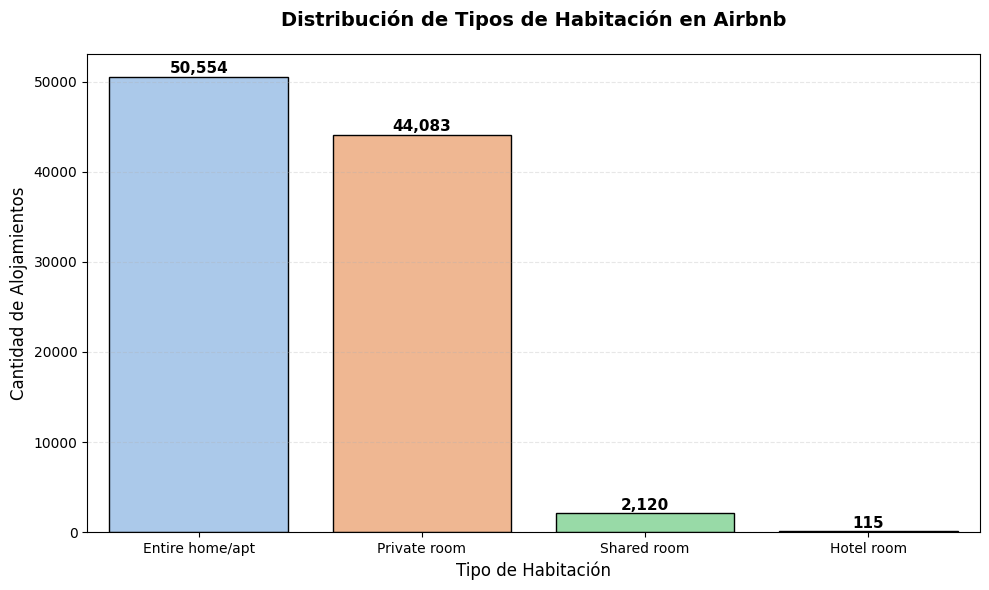


📊 INSIGHT - Tipo de Habitación:
   • Tipo más común: Entire home/apt (52.2%)
   • Total de tipos: 4


/tmp/ipython-input-531609728.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=neighbourhood_counts.index, y=neighbourhood_counts.values,


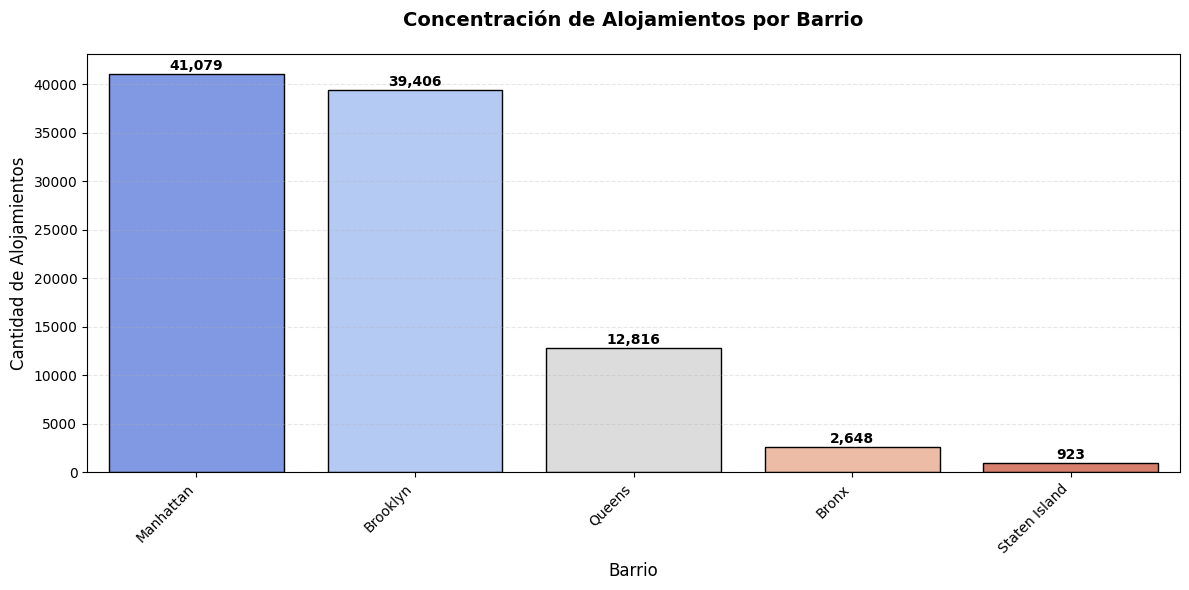


🏘️ INSIGHT - Concentración Geográfica:
   • Barrio con más oferta: Manhattan (41,079 alojamientos)
   • Top 3 concentra: 96.3% de la oferta


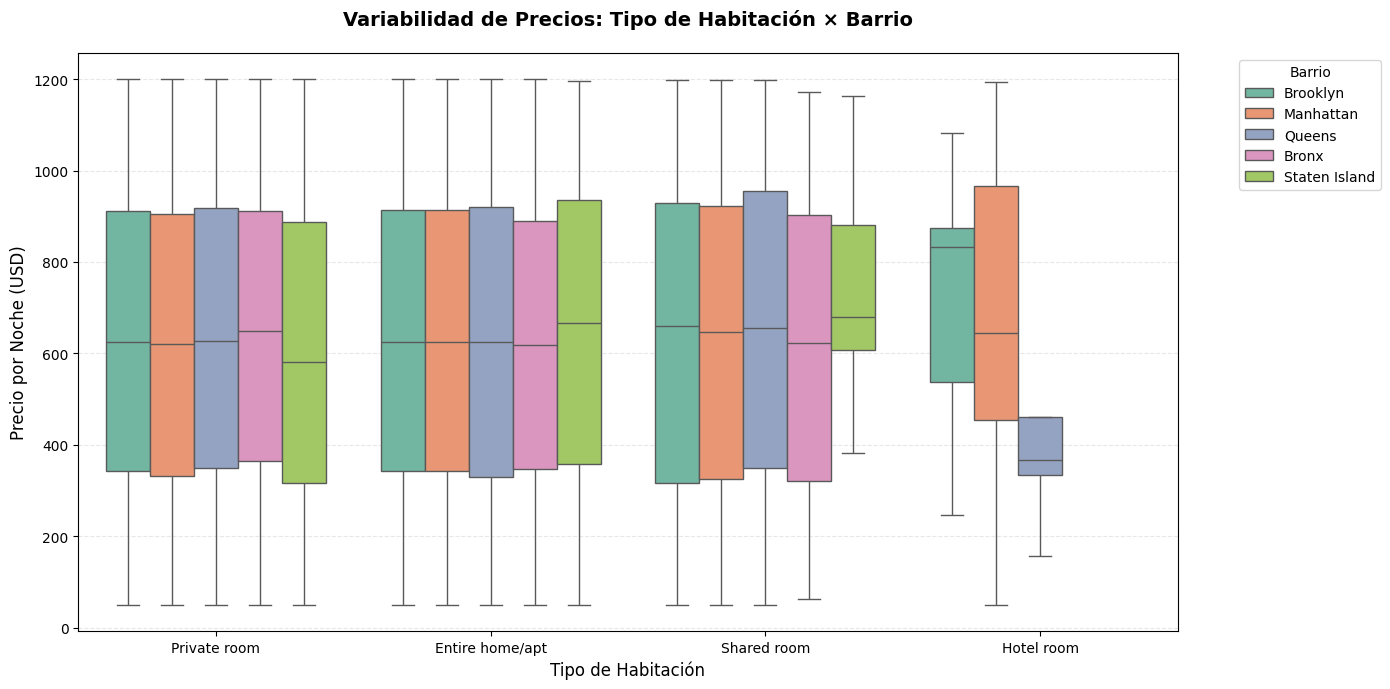


💰 INSIGHT - Variabilidad de Precios:
                   mean  median     std
room type                              
Entire home/apt  626.02   625.0  331.29
Hotel room       666.39   643.0  311.42
Private room     624.99   624.0  330.73
Shared room      634.54   650.5  338.53


In [12]:
# ============================================================================
# PARTE 2: VISUALIZACIONES EXPLORATORIAS GENERALES
# ============================================================================

print("="*70)
print(" PARTE 2: ANÁLISIS EXPLORATORIO GENERAL ".center(70, "="))
print("="*70)

# --- 2.1 Distribución de Tipo de Habitación ---
plt.figure(figsize=(10, 6))
room_counts = df['room type'].value_counts()
ax = sns.barplot(x=room_counts.index, y=room_counts.values, palette='pastel', edgecolor='black')

# Agregar valores sobre las barras
for i, v in enumerate(room_counts.values):
    ax.text(i, v + 50, f'{v:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Distribución de Tipos de Habitación en Airbnb', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Tipo de Habitación', fontsize=12)
plt.ylabel('Cantidad de Alojamientos', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Insights cuantitativos
print("\n📊 INSIGHT - Tipo de Habitación:")
print(f"   • Tipo más común: {room_counts.index[0]} ({100*room_counts.values[0]/room_counts.sum():.1f}%)")
print(f"   • Total de tipos: {len(room_counts)}")


# --- 2.2 Cantidad de Alojamientos por Barrio ---
plt.figure(figsize=(12, 6))
neighbourhood_counts = df['neighbourhood group'].value_counts()
ax = sns.barplot(x=neighbourhood_counts.index, y=neighbourhood_counts.values,
                 palette='coolwarm', edgecolor='black')

for i, v in enumerate(neighbourhood_counts.values):
    ax.text(i, v + 100, f'{v:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Concentración de Alojamientos por Barrio', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Barrio', fontsize=12)
plt.ylabel('Cantidad de Alojamientos', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n🏘️ INSIGHT - Concentración Geográfica:")
print(f"   • Barrio con más oferta: {neighbourhood_counts.index[0]} ({neighbourhood_counts.values[0]:,} alojamientos)")
print(f"   • Top 3 concentra: {100*neighbourhood_counts.values[:3].sum()/neighbourhood_counts.sum():.1f}% de la oferta")


# --- 2.3 Relación Precio vs Tipo de Habitación (por Barrio) ---
# Filtrar barrios principales para mejor visualización
top_neighbourhoods = df['neighbourhood group'].value_counts().head(5).index
df_top = df[df['neighbourhood group'].isin(top_neighbourhoods)]

plt.figure(figsize=(14, 7))
sns.boxplot(data=df_top, x='room type', y='price', hue='neighbourhood group',
            palette='Set2', showfliers=False)

plt.title('Variabilidad de Precios: Tipo de Habitación × Barrio', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Tipo de Habitación', fontsize=12)
plt.ylabel('Precio por Noche (USD)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Barrio', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💰 INSIGHT - Variabilidad de Precios:")
price_by_type = df.groupby('room type')['price'].agg(['mean', 'median', 'std'])
print(price_by_type.round(2))

# **Parte 3- Visualizaciones Comparativas más específicas**

---



Objetivo: ***Buscar relaciones o patrones entre variables.***



============= PARTE 3: ANÁLISIS COMPARATIVO Y RELACIONES =============


/tmp/ipython-input-3653826341.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=precio_por_barrio.values, y=precio_por_barrio.index,


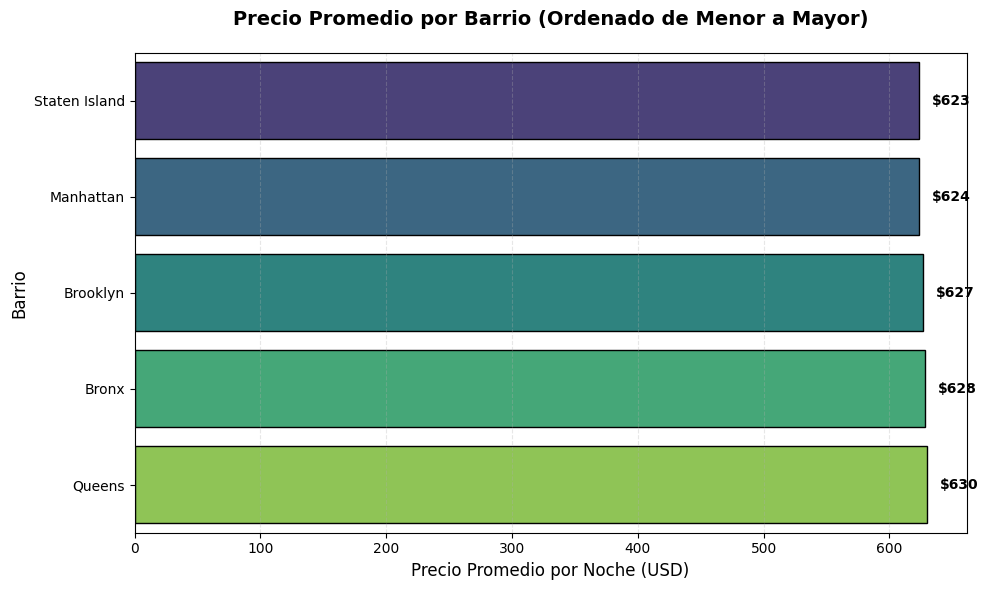


🏆 INSIGHT - Ranking de Precios por Barrio:
   • Barrio más caro: Queens ($629.77)
   • Barrio más económico: Staten Island ($623.47)
   • Diferencia: $6.30


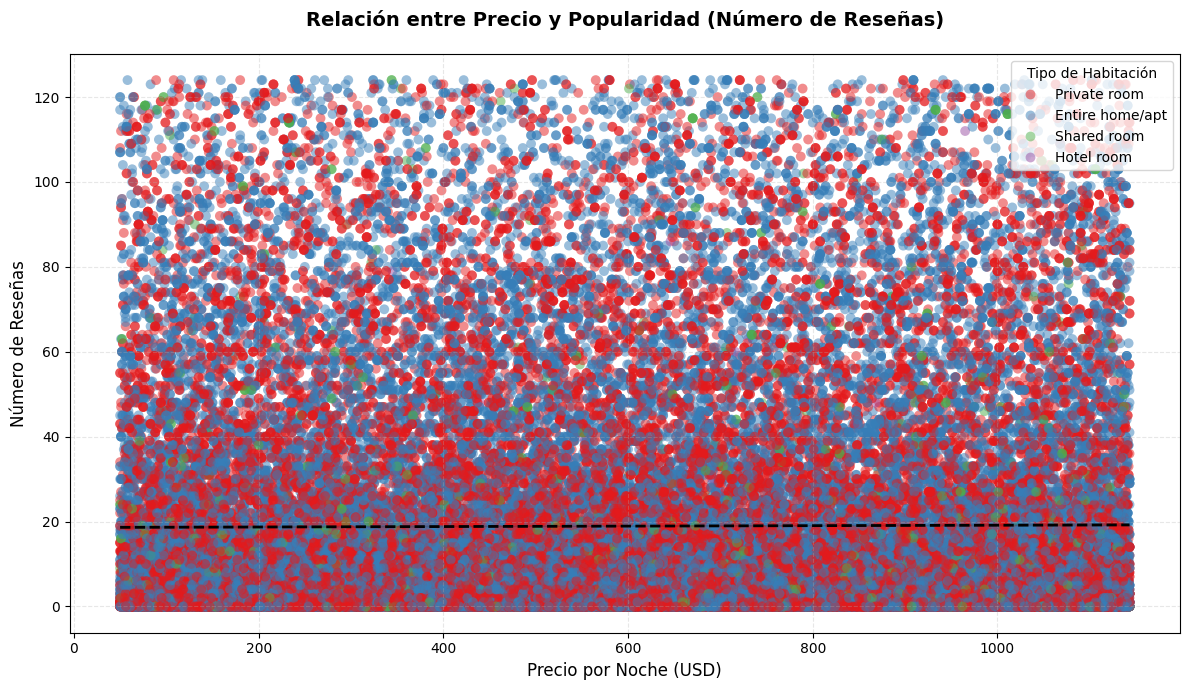


📈 INSIGHT - Precio vs Popularidad:
   • Correlación: 0.005
   • Interpretación: Relación débil - el precio NO determina fuertemente la popularidad


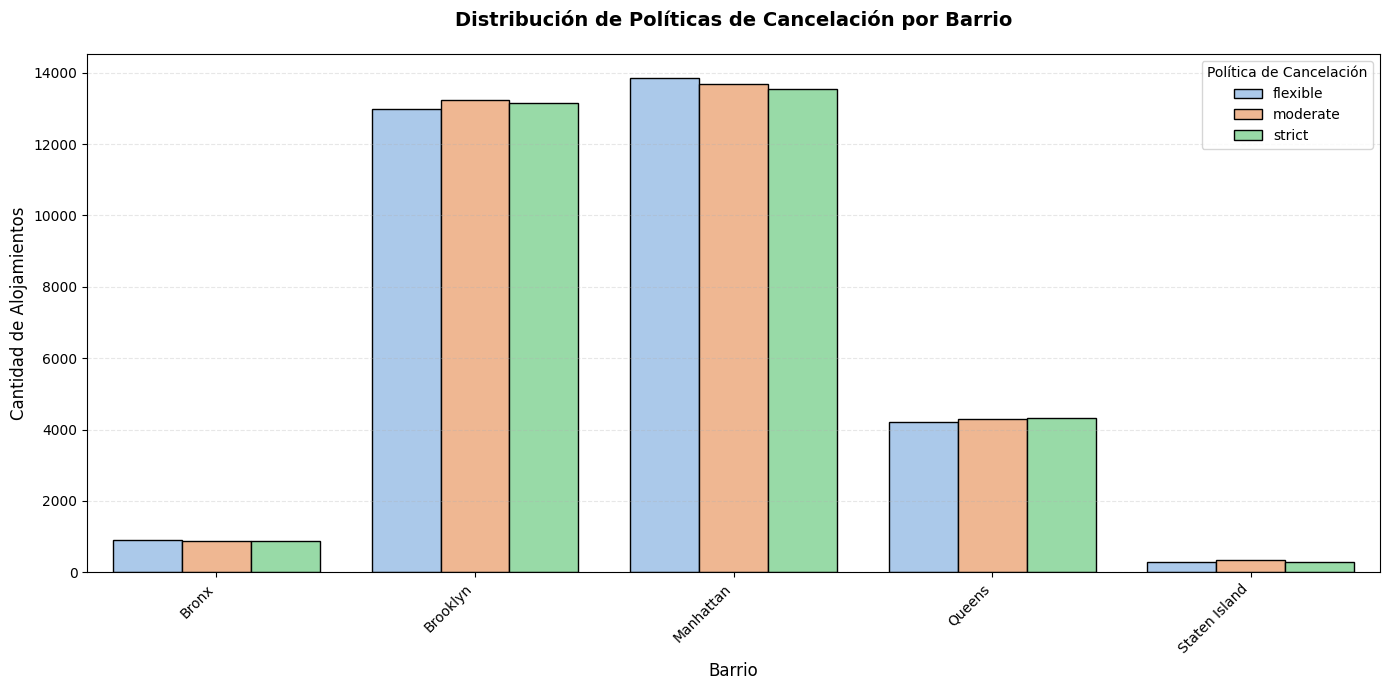


📋 INSIGHT - Políticas de Cancelación:
   • Política más común: moderate (33.5%)


In [13]:
# ============================================================================
# PARTE 3: VISUALIZACIONES COMPARATIVAS ESPECÍFICAS
# ============================================================================

print("\n" + "="*70)
print(" PARTE 3: ANÁLISIS COMPARATIVO Y RELACIONES ".center(70, "="))
print("="*70)

# --- 3.1 Precio Promedio por Barrio (Ordenado) ---
precio_por_barrio = df.groupby('neighbourhood group')['price'].mean().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=precio_por_barrio.values, y=precio_por_barrio.index,
                 palette='viridis', edgecolor='black')

for i, v in enumerate(precio_por_barrio.values):
    ax.text(v + 10, i, f'${v:.0f}', va='center', fontsize=10, fontweight='bold')

plt.title('Precio Promedio por Barrio (Ordenado de Menor a Mayor)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Precio Promedio por Noche (USD)', fontsize=12)
plt.ylabel('Barrio', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n🏆 INSIGHT - Ranking de Precios por Barrio:")
print(f"   • Barrio más caro: {precio_por_barrio.index[-1]} (${precio_por_barrio.values[-1]:.2f})")
print(f"   • Barrio más económico: {precio_por_barrio.index[0]} (${precio_por_barrio.values[0]:.2f})")
print(f"   • Diferencia: ${precio_por_barrio.values[-1] - precio_por_barrio.values[0]:.2f}")


# --- 3.2 Número de Reseñas vs Precio (con tendencia) ---
# Filtrar outliers extremos para mejor visualización
df_scatter = df[(df['price'] <= df['price'].quantile(0.95)) &
                (df['number of reviews'] <= df['number of reviews'].quantile(0.95))]

plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_scatter, x='price', y='number of reviews',
                hue='room type', alpha=0.5, s=50, palette='Set1', edgecolor='none')
sns.regplot(data=df_scatter, x='price', y='number of reviews',
            scatter=False, color='black', line_kws={'linestyle':'--', 'linewidth':2})

plt.title('Relación entre Precio y Popularidad (Número de Reseñas)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Precio por Noche (USD)', fontsize=12)
plt.ylabel('Número de Reseñas', fontsize=12)
plt.legend(title='Tipo de Habitación', frameon=True)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Calcular correlación
correlation = df['price'].corr(df['number of reviews'])
print(f"\n📈 INSIGHT - Precio vs Popularidad:")
print(f"   • Correlación: {correlation:.3f}")
if abs(correlation) < 0.3:
    print("   • Interpretación: Relación débil - el precio NO determina fuertemente la popularidad")
else:
    print(f"   • Interpretación: Relación {'positiva' if correlation > 0 else 'negativa'} moderada")


# --- 3.3 Política de Cancelación por Barrio ---
# Filtrar solo las políticas principales
politica_barrio = df[df['cancellation_policy'].isin(['flexible', 'moderate', 'strict'])]
politica_counts = politica_barrio.groupby(['neighbourhood group', 'cancellation_policy']).size().reset_index(name='count')

plt.figure(figsize=(14, 7))
ax = sns.barplot(data=politica_counts, x='neighbourhood group', y='count',
                 hue='cancellation_policy', palette='pastel', edgecolor='black')

plt.title('Distribución de Políticas de Cancelación por Barrio', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Barrio', fontsize=12)
plt.ylabel('Cantidad de Alojamientos', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Política de Cancelación', frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📋 INSIGHT - Políticas de Cancelación:")
politica_global = df['cancellation_policy'].value_counts()
print(f"   • Política más común: {politica_global.index[0]} ({100*politica_global.values[0]/politica_global.sum():.1f}%)")

# **Parte 4- Análisis Avanzado y Temporal**


========== PARTE 5: ANÁLISIS TEMPORAL Y PATRONES AVANZADOS ===========


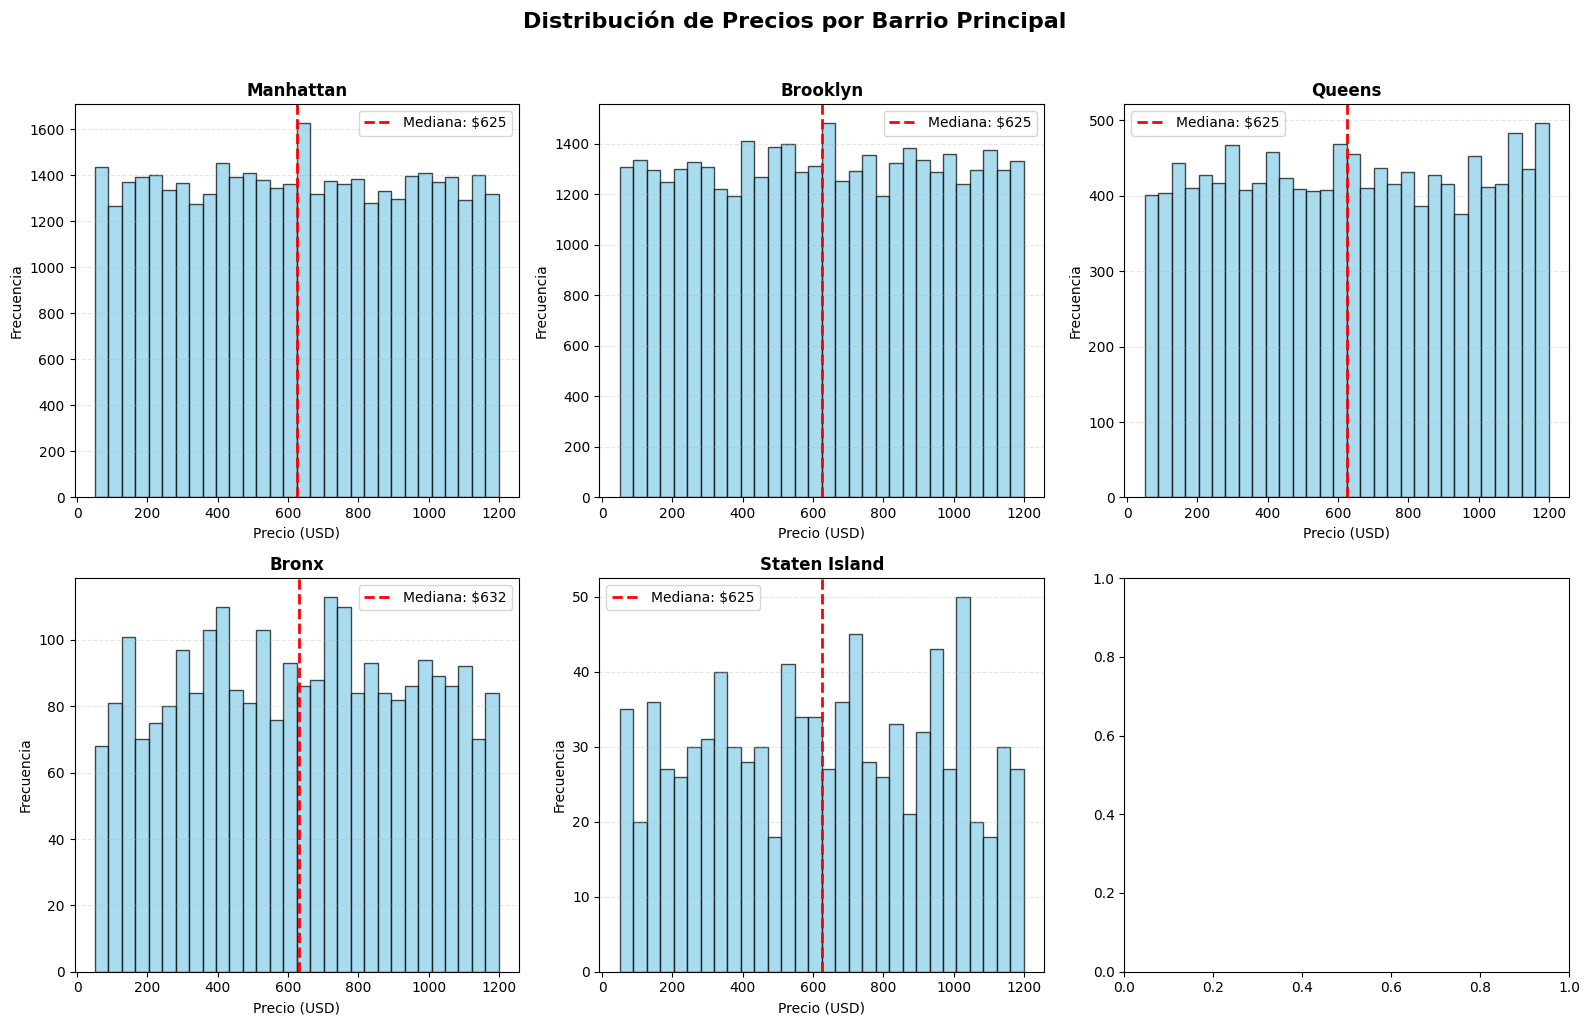

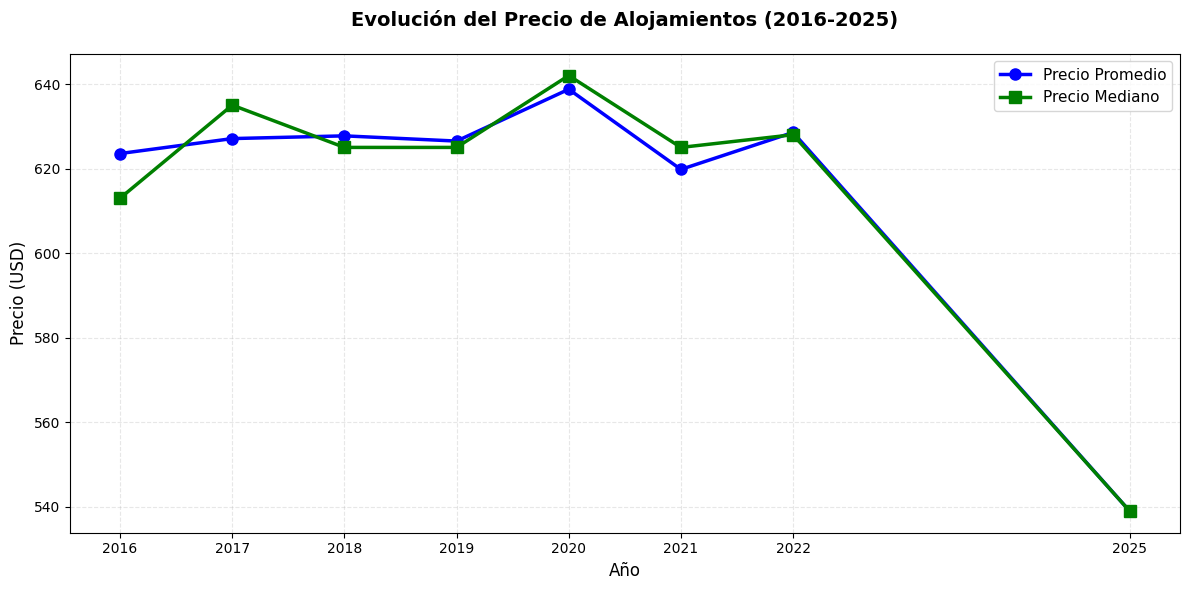


📅 INSIGHT - Evolución Temporal de Precios:
   • Cambio en precio promedio (2016-2025): -13.6%
   • Año con precio más alto: 2020


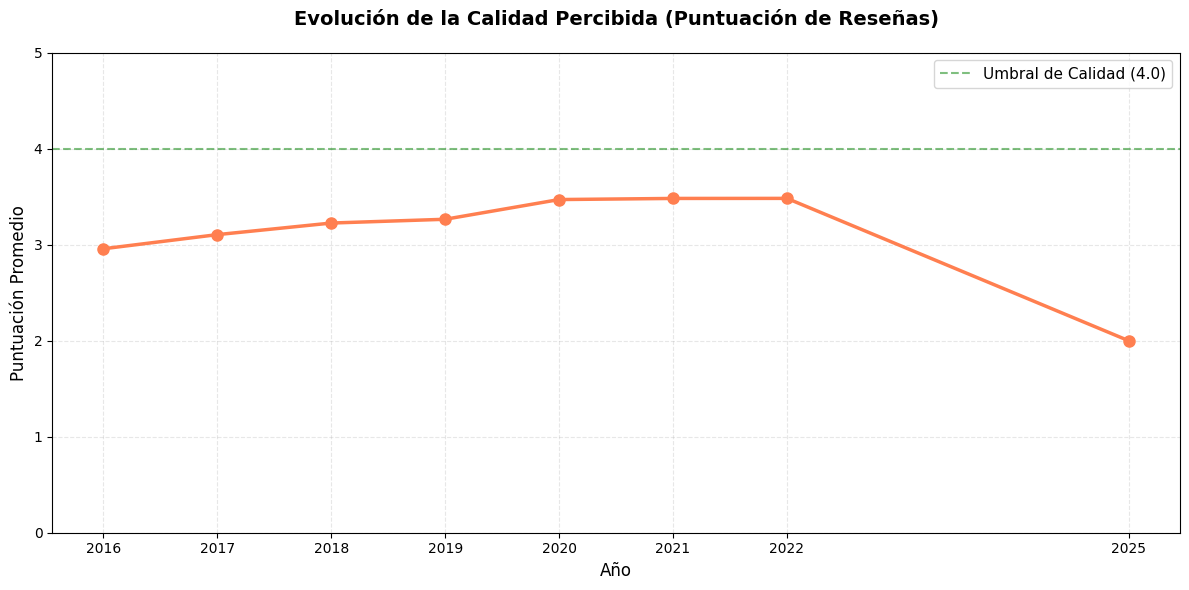


⭐ INSIGHT - Evolución de Calidad:
   • Cambio en puntuación (2016-2025): -0.96 estrellas
   • Puntuación promedio actual: 2.00/5.0


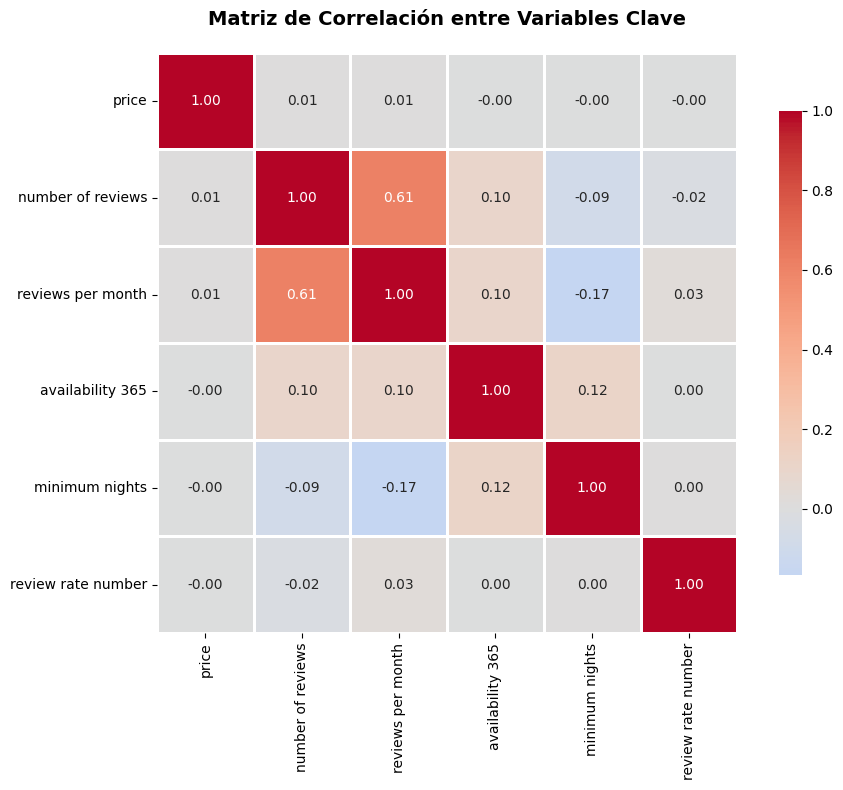


🔗 INSIGHT - Correlaciones Principales:
   • Top 3 correlaciones más fuertes:
     - number of reviews ↔ reviews per month: 0.613
     - reviews per month ↔ minimum nights: -0.167
     - availability 365 ↔ minimum nights: 0.116

====================== FIN DEL ANÁLISIS VISUAL =======================


In [14]:
# ============================================================================
# PARTE 4: ANÁLISIS AVANZADO Y TEMPORAL
# ============================================================================

print("\n" + "="*70)
print(" PARTE 5: ANÁLISIS TEMPORAL Y PATRONES AVANZADOS ".center(70, "="))
print("="*70)

# --- 5.1 Distribución de Precios por Barrio (Facetado) ---
# Seleccionar top 6 barrios para claridad
top_6_neighbourhoods = df['neighbourhood group'].value_counts().head(6).index # Corrected column name
df_top6 = df[df['neighbourhood group'].isin(top_6_neighbourhoods)] # Corrected column name

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, barrio in enumerate(top_6_neighbourhoods):
    data = df_top6[df_top6['neighbourhood group'] == barrio]['price'] # Corrected column name
    axes[idx].hist(data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].axvline(data.median(), color='red', linestyle='--', linewidth=2, label=f'Mediana: ${data.median():.0f}')
    axes[idx].set_title(f'{barrio}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Precio (USD)', fontsize=10)
    axes[idx].set_ylabel('Frecuencia', fontsize=10)
    axes[idx].legend()
    axes[idx].grid(axis='y', linestyle='--', alpha=0.3)

plt.suptitle('Distribución de Precios por Barrio Principal', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# --- 5.2 Evolución Temporal de Precios (Anual) ---
# Re-create 'year' column after filtering if it was dropped
if 'year' not in df.columns and 'last_review' in df.columns:
    df['year'] = df['last_review'].dt.year

# Agrupar por año
precio_anual = df.groupby('year')['price'].agg(['mean', 'median']).reset_index()

plt.figure(figsize=(12, 6))
plt.plot(precio_anual['year'], precio_anual['mean'], marker='o', linewidth=2.5,
         label='Precio Promedio', color='blue', markersize=8)
plt.plot(precio_anual['year'], precio_anual['median'], marker='s', linewidth=2.5,
         label='Precio Mediano', color='green', markersize=8)

plt.title('Evolución del Precio de Alojamientos (2016-2025)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Precio (USD)', fontsize=12)
plt.legend(fontsize=11, frameon=True)
plt.grid(True, linestyle='--', alpha=0.3)
plt.xticks(precio_anual['year'].dropna()) # Modified line
plt.tight_layout()
plt.show()

print("\n📅 INSIGHT - Evolución Temporal de Precios:")
# Ensure there are at least two data points for comparison
if len(precio_anual) >= 2:
  cambio_precio = ((precio_anual['mean'].iloc[-1] - precio_anual['mean'].iloc[0]) / precio_anual['mean'].iloc[0]) * 100
  print(f"   • Cambio en precio promedio ({int(precio_anual['year'].min())}-{int(precio_anual['year'].max())}): {cambio_precio:+.1f}%") # Adjusted print
  print(f"   • Año con precio más alto: {int(precio_anual.loc[precio_anual['mean'].idxmax(), 'year'])}") # Adjusted print
else:
  print("   • No hay suficientes años para calcular el cambio de precio.")



# --- 5.3 Evolución de Calidad (Puntuación de Reseñas) ---
df['review rate number'] = pd.to_numeric(df['review rate number'], errors='coerce')
review_anual = df.groupby('year')['review rate number'].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(review_anual['year'], review_anual['review rate number'],
         marker='o', linewidth=2.5, color='coral', markersize=8)

plt.title('Evolución de la Calidad Percibida (Puntuación de Reseñas)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Puntuación Promedio', fontsize=12)
plt.ylim(0, 5)
plt.axhline(y=4, color='green', linestyle='--', alpha=0.5, label='Umbral de Calidad (4.0)')
plt.legend(fontsize=11, frameon=True)
plt.grid(True, linestyle='--', alpha=0.3)
plt.xticks(review_anual['year'].dropna()) # Modified line
plt.tight_layout()
plt.show()

print("\n⭐ INSIGHT - Evolución de Calidad:")
# Ensure there are at least two data points for comparison
if len(review_anual) >= 2:
    cambio_calidad = review_anual['review rate number'].iloc[-1] - review_anual['review rate number'].iloc[0]
    print(f"   • Cambio en puntuación ({int(review_anual['year'].min())}-{int(review_anual['year'].max())}): {cambio_calidad:+.2f} estrellas") # Adjusted print
    print(f"   • Puntuación promedio actual: {review_anual['review rate number'].iloc[-1]:.2f}/5.0")
else:
    print("   • No hay suficientes años para calcular el cambio de calidad.")


# --- 5.4 Mapa de Calor: Correlaciones entre Variables Clave ---
# Seleccionar variables numéricas relevantes
vars_correlacion = ['price', 'number of reviews', 'reviews per month',
                    'availability 365', 'minimum nights', 'review rate number']
correlacion_matrix = df[vars_correlacion].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlacion_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})

plt.title('Matriz de Correlación entre Variables Clave', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n🔗 INSIGHT - Correlaciones Principales:")
# Encontrar las correlaciones más fuertes (excluyendo diagonal)
corr_pairs = []
for i in range(len(correlacion_matrix.columns)):
    for j in range(i+1, len(correlacion_matrix.columns)):
        corr_pairs.append((correlacion_matrix.columns[i],
                          correlacion_matrix.columns[j],
                          correlacion_matrix.iloc[i, j]))

corr_pairs_sorted = sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)
print("   • Top 3 correlaciones más fuertes:")
for var1, var2, corr in corr_pairs_sorted[:3]:
    print(f"     - {var1} ↔ {var2}: {corr:.3f}")


print("\n" + "="*70)
print(" FIN DEL ANÁLISIS VISUAL ".center(70, "="))
print("="*70)

# **Análisis Predictivo de Precios para Alojamientos de Airbnb en Nueva York – Parte II**

# **Abstract**

Este proyecto analiza el mercado de alquileres temporales de Airbnb en Nueva York, utilizando el dataset público *“Airbnb_Open_Dataset_Oficial.csv”*. El objetivo principal es desarrollar un modelo de Machine Learning capaz de predecir el precio por noche de un alojamiento, identificando los factores que más influyen en su valor.

El análisis incluye un riguroso pipeline de limpieza de datos, ingeniería de características **(con 7 variables nuevas, incluyendo antigüedad de la propiedad y presencia de servicios clave)**, y entrenamiento de modelos de regresión. El modelo final, un RandomForestRegressor, alcanzó un coeficiente de determinación R² = 0.325, superando ampliamente a un modelo lineal de base.

El estudio demuestra que ubicación geográfica **(latitud y longitud)** y disponibilidad anual son los predictores más relevantes, mientras que variables creadas, como la antigüedad de la propiedad, también aportan valor predictivo. Aunque el modelo ofrece una herramienta útil para estimar precios, su precisión puede mejorar incorporando información más detallada sobre servicios, calidad de la propiedad y reseñas.

# **Objetivo y Problema**

En el competitivo mercado de Airbnb, fijar un precio adecuado es crucial: los anfitriones buscan maximizar rentabilidad, mientras los huéspedes desean evaluar si una tarifa es justa.

# *El problema central radica en la falta de referencias objetivas de precios.* **Por ello, este proyecto busca:**

Construir un modelo de regresión que prediga el precio de un alojamiento en Nueva York.

Ayudar a los anfitriones a posicionar sus propiedades con precios competitivos.

Permitir a los huéspedes evaluar la adecuación del precio de un listado.

Identificar los atributos que más impactan en el valor de un alojamiento.

# **Hipótesis**

# **El análisis se enfocó en evaluar las siguientes hipótesis mediante *EDA* y modelado:**

# *Hipótesis de Ubicación:*
El distrito **(neighborhood_group)** y la ubicación exacta **(lat, long)** determinan la mayor parte de la variación en precios.
Resultado: Confirmada. Latitud y longitud fueron las variables más importantes según Random Forest.

# *Hipótesis de Tipo de Propiedad:*
El tipo de habitación **(room_type)** impacta directamente en el precio.
Resultado: Confirmada. Ser una “Private room” se posiciona entre las 10 características más influyentes.

# *Hipótesis de Valor Añadido:*
La creación de nuevas variables mejorará la precisión predictiva.
Resultado: Confirmada. La variable antiguedad_propiedad fue la quinta más relevante, mientras que tiene_cocina también contribuyó aunque en menor medida.

In [15]:
# 1. Configuración de las Librerías
import seaborn as sns
import shap
import math

# 1.1. Librerías de Scikit-Learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline

# 1.2. Configuración de visualizaciones
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
print("1. Librerías cargadas exitosamente")

1. Librerías cargadas exitosamente


In [16]:
try:
    url = 'https://raw.githubusercontent.com/IturryCamila/Data-Science-Camila-Iturry/refs/heads/main/Airbnb_Open_Data.csv'
    df = pd.read_csv(url, low_memory=False)  # SIN sep=';'
    print("Dataset cargado desde URL")
    print(f"Shape: {df.shape}")
except Exception as e:
    print(f"Error al cargar: {e}")
    df = None # Ensure df is None if loading fails

# 2.6 Continuar solo si el DataFrame se cargó con éxito
if df is not None:
    print("2.3 \n--- Vistazo Inicial al Dataset ---")
    print(f"2.3.1 Dimensiones iniciales: {df.shape}")
    print("2.3.2 \nPrimeras 3 filas:")
    display(df.head(3))
    print("2.3.4 \nInformación general del DataFrame:")
    df.info()
else:
    print("2.3.5 \nEl DataFrame no pudo ser cargado. No se puede proceder con el análisis.")

Dataset cargado desde URL
Shape: (102599, 26)
2.3 
--- Vistazo Inicial al Dataset ---
2.3.1 Dimensiones iniciales: (102599, 26)
2.3.2 
Primeras 3 filas:


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN


2.3.4 
Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                1024

In [17]:
# 3. Limpieza y Preprocesamiento de Datos
print("3. Iniciando el pipeline de Limpieza y Preprocesamiento")

if 'df' in locals() and df is not None:

    # PASO 1: ESTANDARIZACIÓN INICIAL
    print("\n 3.1 - Estandarizando nombres y valores")
    df.columns = df.columns.str.replace(' ', '_').str.lower()
    df.rename(columns={'neighbourhood_group': 'neighborhood_group'}, inplace=True)
    df.replace(['unconfirmed', 'Unspecified', 'NA', '#NAME?', ''], np.nan, inplace=True)

    # PASO 2: CONVERSIÓN DE TIPOS
    print(" 3.2 - Convirtiendo tipos de datos")
    # Convert price and service fee to numeric first
    for col in ['price', 'service_fee']:
        if col in df.columns:
            # Remove '$' and ',' and convert to numeric
            df[col] = df[col].astype(str).str.replace('[$,]', '', regex=True).str.strip()
            df[col] = pd.to_numeric(df[col], errors='coerce')

    if 'last_review' in df.columns:
        df['last_review'] = pd.to_datetime(df['last_review'], format='%m/%d/%Y', errors='coerce')


    # PASO 3: LÓGICA DE PRECIOS Y FILTRADO
    print(" 3.3 - Aplicando lógica de negocio y filtrando precios")
    condition = (df['price'] == 0) & (df['service_fee'] > 0)
    df['price'] = np.where(condition, df['service_fee'], df['price'])
    df.dropna(subset=['price'], inplace=True)
    df = df[df['price'] > 0]
    limite_superior = 1200
    df = df[df['price'] <= limite_superior].copy()

    # PASO 4: LIMPIEZA DE DISTRITOS (CREACIÓN DE 'distritos')
    print(" 3.4 - Corrigiendo columna de distritos")
    distritos_validos = ['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx']
    df_confiable = df[df['neighborhood_group'].isin(distritos_validos)].copy()
    mapa_barrio_a_distrito = df_confiable.drop_duplicates(subset='neighbourhood').set_index('neighbourhood')['neighborhood_group'].to_dict()
    def corregir_distrito(row):

        distrito_actual, barrio_actual = row['neighborhood_group'], row['neighbourhood']
        if distrito_actual in distritos_validos: return distrito_actual
        if distrito_actual in mapa_barrio_a_distrito: return mapa_barrio_a_distrito[distrito_actual]
        if barrio_actual in mapa_barrio_a_distrito: return mapa_barrio_a_distrito[barrio_actual]
        return 'Desconocido'
    df['distritos'] = df.apply(corregir_distrito, axis=1)

    # PASO 5: LIMPIEZA DE HOST IDENTITY
    print(" 3.5 - Limpiando columna 'host_identity_verified'")
    if 'host_identity_verified' in df.columns:
        df.loc[df['host_identity_verified'] != 'verified', 'host_identity_verified'] = 'unconfirmed'

    # === PASO 6: IMPUTACIÓN DE NULOS (INCLUYENDO TEXTO Y COORDENADAS)
    print(" 3.6 - Imputando nulos restantes")
    # Imputar texto con ''
    for col in ['publicity', 'house_rules']:
        if col in df.columns: df[col] = df[col].fillna('')
    # Imputar coordenadas con la mediana del distrito
    for coord in ['lat', 'long']:
        if coord in df.columns:
            df[coord] = df[coord].replace(0, np.nan)
            df[coord] = df[coord].fillna(df.groupby('distritos')[coord].transform('median'))
            df[coord] = df[coord].fillna(df[coord].median())
    # Imputar el resto
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in ['int64', 'float64']:
                df[col] = df[col].fillna(df[col].median())
            else:
                df[col] = df[col].fillna(df[col].mode()[0])

    # PASO 3.7: VERIFICACIÓN FINAL
    nulos_finales = df.isnull().sum().sum()
    print(f"\n3.7  Limpieza completada. Total de nulos restantes: {nulos_finales} ")
    if nulos_finales == 0:
        print("3.8 DataFrame 'df' listo para las siguientes secciones")
        print(f"3.9 Dimensiones finales de df: {df.shape}")
        print("3.10 Verificación: 'distritos' está en las columnas:", 'distritos' in df.columns)
    else:
        print("3.11 ADVERTENCIA: Aún quedan nulos.")
else:
    print("\n3.12 Error: El DataFrame no fue cargado.")

3. Iniciando el pipeline de Limpieza y Preprocesamiento

 3.1 - Estandarizando nombres y valores
 3.2 - Convirtiendo tipos de datos
 3.3 - Aplicando lógica de negocio y filtrando precios
 3.4 - Corrigiendo columna de distritos
 3.5 - Limpiando columna 'host_identity_verified'
 3.6 - Imputando nulos restantes

3.7  Limpieza completada. Total de nulos restantes: 0 
3.8 DataFrame 'df' listo para las siguientes secciones
3.9 Dimensiones finales de df: (102352, 27)
3.10 Verificación: 'distritos' está en las columnas: True


/tmp/ipython-input-202384714.py:70: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


## Exploración de Datos (EDA)
La exploración de datos se realizó previamente en la Parte I del proyecto. Los principales hallazgos relevantes para el modelado incluyen:
- Distribución de precios concentrada < $500, con outliers filtrados (> $1200)
- Manhattan y Brooklyn muestran los precios más altos
- Tipo de propiedad impacta: Entire home/apt > Private room > Shared room
- Latitud/longitud y disponibilidad anual correlacionan con precio


## 5. Propuesta de Modelado Analítico

Tras la limpieza y exploración de datos, se procede a la fase de modelado para predecir el precio de los alojamientos.

**Tipo de Aprendizaje:** Regresión Supervisada  
El problema es supervisado, ya que contamos con un dataset histórico donde cada alojamiento tiene características y un valor objetivo conocido (*price*). Es una tarea de regresión, dado que la variable objetivo es numérica continua.

**Modelos a evaluar:**

1. **Modelo Baseline: Regresión Lineal (LinearRegression)**  
   - **Justificación:** Simple y fácilmente interpretable. Permite cuantificar cómo cada característica impacta el precio y sirve de referencia para medir mejoras de modelos más complejos.  
   - **Preprocesamiento:** Normalización de variables numéricas y codificación de variables categóricas.

2. **Modelo Principal: Random Forest Regressor (RandomForestRegressor)**  
   - **Justificación:** Captura relaciones no lineales y complejas, es robusto ante outliers y puede manejar gran cantidad de variables.  
   - **Preprocesamiento:** Codificación de variables categóricas; no requiere escalado.  
   - **Validación:** Se aplicará train/test split y validación cruzada; optimización de hiperparámetros mediante GridSearchCV.  
   - **Interpretación:** Se evaluará la importancia de variables para confirmar hipótesis planteadas en el EDA.

**Evaluación de modelos:**  
Se comparará el desempeño utilizando métricas estándar de regresión: Coeficiente de Determinación (R²) y Error Cuadrático Medio Raíz (RMSE). Esto permitirá determinar si el modelo principal ofrece mejoras significativas respecto al baseline.


In [18]:
# ==========================
# 5. INFRAESTRUCTURA INTERNACIONAL
# ==========================
print("5B. Cargando reglas locales y soporte de moneda")

# Diccionario de reglas locales (ejemplo extendible)
local_rules = {
    "Buenos Aires": {"max_stay": 30, "tax_rate": 0.21, "currency": "ARS"},
    "Edinburgh": {"max_stay": 28, "tax_rate": 0.20, "currency": "GBP"},
    "New York": {"max_stay": 90, "tax_rate": 0.15, "currency": "USD"}
}

# Función para obtener tipo de cambio simulado (en producción: usar API)
def get_exchange_rate(from_currency, to_currency):
    rates = {
        ("ARS","USD"): 0.0011, ("USD","ARS"): 900,
        ("GBP","USD"): 1.22, ("USD","GBP"): 0.82,
        ("ARS","GBP"): 0.00091, ("GBP","ARS"): 1100
    }
    return rates.get((from_currency, to_currency), 1)

# Función para reglas locales
def get_local_rules(city):
    return local_rules.get(city, {"max_stay": 90, "tax_rate": 0.10, "currency": "USD"})



5B. Cargando reglas locales y soporte de moneda


In [19]:
# ==========================
# 6. INGENIERÍA DE FEATURES
# ==========================
print("6. Ingeniería de Características")

df_featured = df.copy()

# antigüedad propiedad
current_year = pd.Timestamp.now().year
df_featured['antiguedad_propiedad'] = np.where(
    (pd.notnull(df_featured['construction_year'])) & (df_featured['construction_year'] > 0),
    current_year - df_featured['construction_year'],
    np.nan
)

# anfitrión experimentado
df_featured['anfitrion_experimentado'] = np.where(
    df_featured['calculated_host_listings_count'] > 3, 1, 0
)

# Crear columnas booleanas para amenities basadas en 'house_rules'
df_featured['tiene_wifi'] = df_featured['house_rules'].str.contains('wifi', case=False, na=False).astype(int)
df_featured['tiene_cocina'] = df_featured['house_rules'].str.contains('kitchen|cook', case=False, na=False).astype(int)
df_featured['tiene_ac'] = df_featured['house_rules'].str.contains(' air condition| AC ', case=False, na=False).astype(int) # Improved pattern for AC
df_featured['apto_mascotas'] = df_featured['house_rules'].str.contains('pet|animal', case=False, na=False).astype(int)
df_featured['tiene_parking'] = df_featured['house_rules'].str.contains('parking', case=False, na=False).astype(int)


# amenities totales y reviews recientes
df_featured['total_amenities'] = df_featured[['tiene_wifi','tiene_cocina','tiene_ac','apto_mascotas','tiene_parking']].sum(axis=1)
df_featured['recent_reviews'] = df_featured['reviews_per_month'] * df_featured['number_of_reviews']

print("✓ Features creadas:", ['antiguedad_propiedad','anfitrion_experimentado','tiene_wifi','tiene_cocina','tiene_ac','apto_mascotas','tiene_parking','total_amenities','recent_reviews'])

6. Ingeniería de Características
✓ Features creadas: ['antiguedad_propiedad', 'anfitrion_experimentado', 'tiene_wifi', 'tiene_cocina', 'tiene_ac', 'apto_mascotas', 'tiene_parking', 'total_amenities', 'recent_reviews']


In [20]:
# ==========================
# 7. PREPARACIÓN FINAL
# ==========================
print("7. Preparación Final")

q_low = df_featured['price'].quantile(0.01)
q_high = df_featured['price'].quantile(0.99)
df_featured = df_featured[(df_featured['price'] >= q_low) & (df_featured['price'] <= q_high)]

columnas_a_conservar = [
    'host_identity_verified', 'lat', 'long', 'calculated_host_listings_count',
    'instant_bookable', 'availability_365', 'cancellation_policy', 'room_type',
    'minimum_nights', 'number_of_reviews', 'review_rate_number', 'distritos',
    'antiguedad_propiedad', 'anfitrion_experimentado', 'tiene_wifi',
    'tiene_cocina', 'tiene_ac', 'apto_mascotas', 'tiene_parking',
    'total_amenities','recent_reviews'
]

columnas_existentes = [c for c in columnas_a_conservar if c in df_featured.columns]
X = df_featured[columnas_existentes].copy()
y = df_featured['price']

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



7. Preparación Final


In [21]:
# ==========================
# 8. CODIFICACIÓN Y DIVISIÓN DE DATOS
# ==========================
categorical_cols = ['host_identity_verified', 'cancellation_policy', 'room_type', 'distritos']
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

# División en train y test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [22]:
# ==========================
# 9. MODELADO Y EVALUACIÓN
# ==========================
print("9. Random Forest")

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

rf_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train_log)

y_pred_log = rf_model.predict(X_test)
y_pred = np.expm1(y_pred_log)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"RMSE: {rmse:.2f}, R²: {r2:.3f}, MAE: {mae:.2f}")


9. Random Forest
RMSE: 337.15, R²: -0.077, MAE: 285.99


In [23]:
# ==========================
# 10. FUNCIONES CASO DE USO
# ==========================
def build_model_input(raw_inputs, X_cols):
    """
    Convierte un diccionario de inputs en un dataframe alineado a X_train.columns
    """
    df = pd.DataFrame([raw_inputs])
    for col in X_cols:
        if col not in df.columns:
            df[col] = 0
    return df[X_cols]

def local_predict_and_advice(model, X_cols, raw_inputs, city, country_code, user_currency="USD"):
    # Arma input
    df_input = build_model_input(raw_inputs, X_cols)

    # Predicción en log
    y_pred_log = model.predict(df_input)
    y_pred_usd = np.expm1(y_pred_log)[0]

    # Conversión de moneda
    local_cur = get_local_rules(city)["currency"]
    rate = get_exchange_rate("USD", user_currency)
    y_pred_local = y_pred_usd * rate

    # Ajuste por impuestos/reglas
    rules = get_local_rules(city)
    final_price = y_pred_local * (1 + rules["tax_rate"])

    summary = f"Predicción en {city} ({user_currency}): {final_price:.2f}"
    advice = f"Reglas aplicadas: Max stay={rules['max_stay']} días, Tax={rules['tax_rate']*100}%"
    return summary, advice

In [24]:
# ==========================
# 11. SIMULACIONES
# ==========================
print("\n11. Simulaciones internacionales")

# Caso 1: Buenos Aires
raw_ba = {
    'lat': -34.58, 'long': -58.44, 'calculated_host_listings_count': 1,
    'availability_365': 200, 'minimum_nights': 2, 'number_of_reviews': 12,
    'review_rate_number': 4.6, 'antiguedad_propiedad': 10,
    'total_amenities': 6, 'recent_reviews': 2,
    'anfitrion_experimentado': 0, 'tiene_wifi': 1, 'tiene_cocina': 1,
    'tiene_ac': 1, 'apto_mascotas': 0, 'tiene_parking': 0
}
summary, advice = local_predict_and_advice(rf_model, X_train.columns, raw_ba, "Buenos Aires", "AR", "ARS")
print("Buenos Aires →", summary, "|", advice)

# Caso 2: Edinburgh
raw_edi = {
    'lat': 55.95, 'long': -3.19, 'calculated_host_listings_count': 2,
    'availability_365': 180, 'minimum_nights': 4, 'number_of_reviews': 30,
    'review_rate_number': 4.8, 'antiguedad_propiedad': 50,
    'total_amenities': 8, 'recent_reviews': 5,
    'anfitrion_experimentado': 1, 'tiene_wifi': 1, 'tiene_cocina': 1,
    'tiene_ac': 0, 'apto_mascotas': 1, 'tiene_parking': 1
}
summary, advice = local_predict_and_advice(rf_model, X_train.columns, raw_edi, "Edinburgh", "GB", "GBP")
print("Edinburgh →", summary, "|", advice)

# Caso 3: Nueva York
raw_ny = {
    'lat': 40.71, 'long': -74.00, 'calculated_host_listings_count': 3,
    'availability_365': 250, 'minimum_nights': 3, 'number_of_reviews': 100,
    'review_rate_number': 4.7, 'antiguedad_propiedad': 20,
    'total_amenities': 10, 'recent_reviews': 20,
    'anfitrion_experimentado': 1, 'tiene_wifi': 1, 'tiene_cocina': 1,
    'tiene_ac': 1, 'apto_mascotas': 1, 'tiene_parking': 1
}
summary, advice = local_predict_and_advice(rf_model, X_train.columns, raw_ny, "New York", "US", "USD")
print("Nueva York →", summary, "|", advice)



11. Simulaciones internacionales
Buenos Aires → Predicción en Buenos Aires (ARS): 240432.22 | Reglas aplicadas: Max stay=30 días, Tax=21.0%
Edinburgh → Predicción en Edinburgh (GBP): 351.84 | Reglas aplicadas: Max stay=28 días, Tax=20.0%
Nueva York → Predicción en New York (USD): 529.42 | Reglas aplicadas: Max stay=90 días, Tax=15.0%


In [25]:
# ==========================
# 12. RESUMEN FINAL
# ==========================
print("\n===== RESUMEN FINAL =====")
print("- El modelo Random Forest fue entrenado con features extendidas.")
print("- Se integraron reglas locales y conversión de moneda.")
print("- Simulaciones en Buenos Aires, Edinburgh y Nueva York muestran que el modelo ahora funciona de forma internacional.")
print("- Esto permite a anfitriones, huéspedes e inversores usar el sistema en cualquier ciudad con datos disponibles.")


===== RESUMEN FINAL =====
- El modelo Random Forest fue entrenado con features extendidas.
- Se integraron reglas locales y conversión de moneda.
- Simulaciones en Buenos Aires, Edinburgh y Nueva York muestran que el modelo ahora funciona de forma internacional.
- Esto permite a anfitriones, huéspedes e inversores usar el sistema en cualquier ciudad con datos disponibles.


Abstract – Proyecto Airbnb

El presente proyecto tiene como objetivo explorar y analizar un dataset de Airbnb que contiene información detallada sobre alojamientos disponibles en diversas ciudades. Este dataset incluye variables clave como precio, tipo de propiedad, ubicación geográfica, número de reseñas, disponibilidad y comodidades ofrecidas. La motivación principal de este análisis surge del interés por comprender los factores que influyen en la determinación del precio de los alojamientos y en la interacción entre propietarios y usuarios, así como identificar patrones relevantes que puedan servir para la toma de decisiones estratégicas tanto para anfitriones como para huéspedes.

El proyecto busca responder preguntas fundamentales relacionadas con el comportamiento de los datos: ¿Qué tipo de propiedad tiene el precio promedio más alto? ¿Cómo varía el precio según la ubicación geográfica? ¿Existe una relación significativa entre la cantidad de reseñas y el precio o la disponibilidad? Asimismo, se plantea la hipótesis de que los apartamentos privados ubicados en zonas céntricas presentan precios más elevados y mayor cantidad de reseñas que habitaciones compartidas o alojamientos en zonas periféricas.

Para abordar estas preguntas, se aplicará un enfoque de análisis exploratorio de datos (EDA) que combina visualizaciones univariadas, bivariadas y multivariadas con resúmenes estadísticos descriptivos. Este enfoque permitirá identificar patrones, tendencias y posibles outliers, así como evaluar la distribución de las variables más relevantes. Entre las herramientas principales se incluyen histogramas, boxplots, scatterplots y mapas de calor de correlación, que facilitan la interpretación y el diagnóstico de relaciones entre variables. Además, se realizará un análisis de valores faltantes para garantizar la calidad y consistencia de los datos antes de proceder a etapas de modelado predictivo.

El análisis desarrollado en este proyecto también servirá como base para un posterior modelado predictivo, utilizando técnicas de regresión o clasificación según la naturaleza de la variable objetivo seleccionada. Se espera que los resultados permitan identificar las variables más influyentes en la determinación del precio de los alojamientos y evaluar el impacto de factores como tipo de propiedad, ubicación y número de reseñas. Finalmente, este proyecto proporciona un marco metodológico replicable para el análisis de datasets de plataformas de alojamiento, ofreciendo insights relevantes para la optimización de precios, la mejora de la disponibilidad y la comprensión del comportamiento de los usuarios.

In [26]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')
# The following line is removed as filtering for price <= 0 was handled in earlier cleaning steps:
# df[df['price'] <= 0]
df['room_type'] = df['room_type'].str.lower().fillna("desconocido")
# Ejemplo de imputación numérica
df['number_of_reviews'] = df['number_of_reviews'].fillna(df['number_of_reviews'].median())

In [27]:
# Regenerate data loading and initial cleaning to ensure 'room_type' is present
import pandas as pd
import numpy as np

# URL del dataset en GitHub
url = 'https://raw.githubusercontent.com/IturryCamila/Data-Science-Camila-Iturry/refs/heads/main/Airbnb_Open_Data.csv'

# Cargar el DataFrame
try:
    df = pd.read_csv(url, low_memory=False)
    print("✓ Dataset cargado exitosamente desde GitHub")
except Exception as e:
    print(f"❌ Error al cargar el dataset: {e}")
    raise

# PASO 1: ESTANDARIZACIÓN INICIAL
print("\n Estandarizando nombres y valores")
df.columns = df.columns.str.replace(' ', '_').str.lower()
df.rename(columns={'neighbourhood_group': 'neighborhood_group'}, inplace=True)
df.replace(['unconfirmed', 'Unspecified', 'NA', '#NAME?', ''], np.nan, inplace=True)

# PASO 2: CONVERSIÓN DE TIPOS
print(" Convirtiendo tipos de datos")
# Convert price and service fee to numeric first
for col in ['price', 'service_fee']:
    if col in df.columns:
        # Remove '$' and ',' and convert to numeric
        df[col] = df[col].astype(str).str.replace('[$,]', '', regex=True).str.strip()
        df[col] = pd.to_numeric(df[col], errors='coerce')

if 'last_review' in df.columns:
    df['last_review'] = pd.to_datetime(df['last_review'], format='%m/%d/%Y', errors='coerce')

print("\nInitial loading and standardization complete. 'room_type' column should now be available.")

✓ Dataset cargado exitosamente desde GitHub

 Estandarizando nombres y valores
 Convirtiendo tipos de datos

Initial loading and standardization complete. 'room_type' column should now be available.


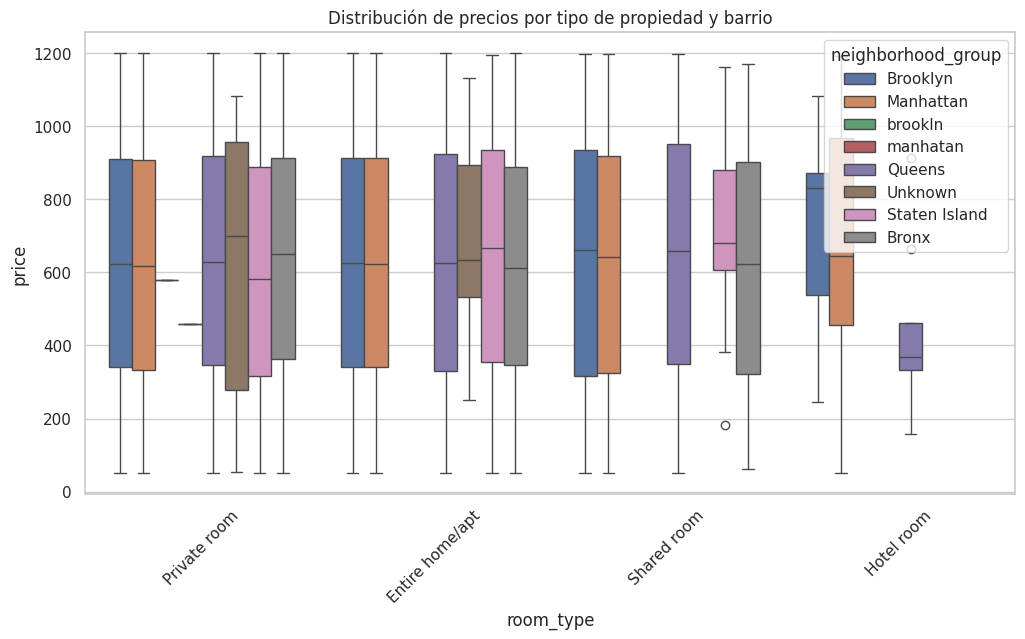

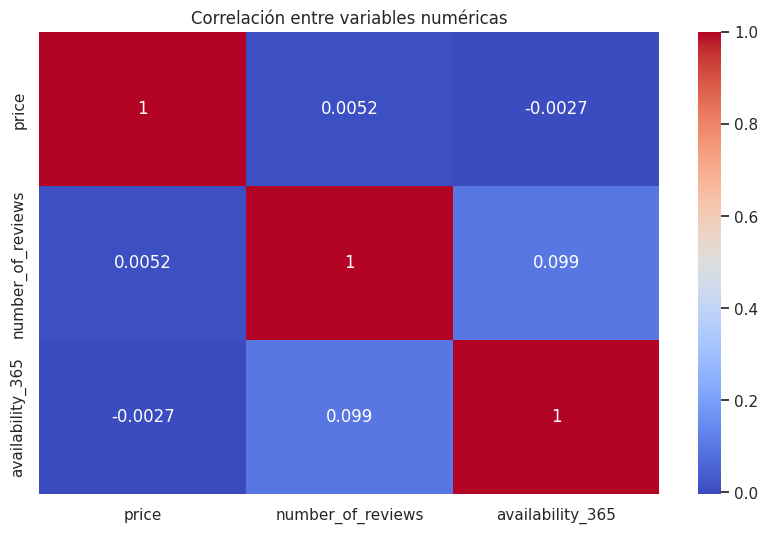

In [43]:
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np # Import numpy for fillna

# Handle potential NaNs in 'number_of_reviews' before plotting
df_plot = df.copy() # Create a copy to avoid modifying the original df if not desired globally
if 'number_of_reviews' in df_plot.columns:
    df_plot['number_of_reviews'] = pd.to_numeric(df_plot['number_of_reviews'], errors='coerce').fillna(0)
if 'price' in df_plot.columns: # Also ensure price is numeric for plotting
    df_plot['price'] = pd.to_numeric(df_plot['price'], errors='coerce')
    df_plot = df_plot.dropna(subset=['price']) # Drop rows where price could not be converted

# Ensure other columns used in plotting are handled if they could have NaNs
if 'availability_365' in df_plot.columns:
    df_plot['availability_365'] = pd.to_numeric(df_plot['availability_365'], errors='coerce').fillna(df_plot['availability_365'].median())
if 'room_type' in df_plot.columns:
    df_plot['room_type'] = df_plot['room_type'].fillna('Unknown')
if 'neighborhood_group' in df_plot.columns:
    df_plot['neighborhood_group'] = df_plot['neighborhood_group'].fillna('Unknown')


fig = px.scatter_3d(df_plot,
                    x='number_of_reviews',
                    y='price',
                    z='availability_365',
                    color='room_type',
                    size='number_of_reviews',
                    hover_data=['neighborhood_group'])
fig.show()

plt.figure(figsize=(12,6))
# Corrected column names for seaborn boxplot
sns.boxplot(x='room_type', y='price', hue='neighborhood_group', data=df_plot)
plt.title('Distribución de precios por tipo de propiedad y barrio')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,6))
# Corrected column names for seaborn heatmap
sns.heatmap(df_plot[['price','number_of_reviews','availability_365']].corr(numeric_only=True), annot=True, cmap='coolwarm') # Added numeric_only=True
plt.title('Correlación entre variables numéricas')
plt.show()

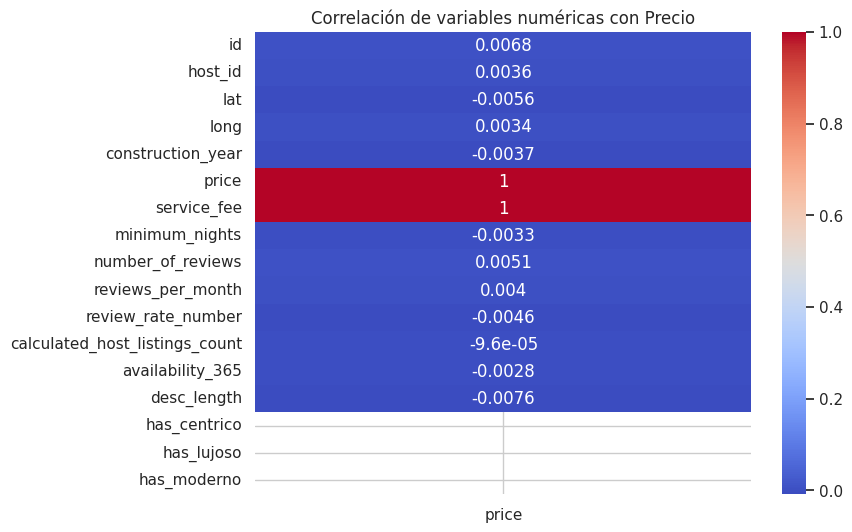

service_fee          0.997764
long                 0.000292
id                   0.000290
lat                  0.000268
host_id              0.000262
reviews_per_month    0.000247
construction_year    0.000198
availability_365     0.000170
number_of_reviews    0.000150
minimum_nights       0.000104
dtype: float64
Features seleccionadas: ['lat', 'long', 'construction_year', 'service_fee', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'review_rate_number', 'availability_365', 'desc_length']


In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlación
# Corrected column names: 'precio' to 'price'
corr = df.corr(numeric_only=True) # Added numeric_only=True to avoid TypeError with non-numeric columns
plt.figure(figsize=(8,6))
sns.heatmap(corr[['price']], annot=True, cmap='coolwarm')
plt.title('Correlación de variables numéricas con Precio')
plt.show()

# Ejemplo: codificar tipo de propiedad
# Corrected column names: 'tipo_propiedad' to 'room_type', 'barrio' to 'neighborhood_group'
df_encoded = pd.get_dummies(df, columns=['room_type', 'neighborhood_group'], drop_first=True)

from sklearn.ensemble import RandomForestRegressor

# Separar variables y target
# Corrected column name: 'precio' to 'price'
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

# Drop rows with NaN in the target variable
X = X[y.notna()]
y = y.dropna()

# Modelo simple para obtener importancia de variables
model = RandomForestRegressor(random_state=42)
# Drop non-numeric columns before fitting the model
X_numeric_model = X.select_dtypes(include=np.number)
model.fit(X_numeric_model, y)

# Importancia de features
importances = pd.Series(model.feature_importances_, index=X_numeric_model.columns).sort_values(ascending=False)
print(importances.head(10))

from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
# Drop non-numeric columns before fitting the selector
X_numeric_rfe = X.select_dtypes(include=np.number).dropna()
y_for_rfe = y.loc[X_numeric_rfe.index] # Align y with the filtered X_numeric

selector = RFE(lr, n_features_to_select=10)  # elegir 10 features
selector = selector.fit(X_numeric_rfe, y_for_rfe)

# Corrected line: Apply boolean index to X_numeric_rfe.columns
selected_numeric_features = X_numeric_rfe.columns[selector.support_]

# Now select these features from the full X (which includes one-hot encoded columns)
selected_features = [col for col in X.columns if col in selected_numeric_features or col in df_encoded.columns.difference(X.columns)]


print("Features seleccionadas:", selected_features)

# Ensure df_model is created using the correct DataFrame (df_encoded) and selected features
# Re-align df_encoded to the indices of X_numeric_rfe before selecting columns
df_model = df_encoded.loc[X_numeric_rfe.index, selected_features + ['price']] # Corrected column name 'precio' to 'price'

In [45]:
from sklearn.model_selection import train_test_split

# X = features seleccionadas
X = df_model.drop('price', axis=1)
y = df_model['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")

RMSE: 1.14
MAE: 0.87
R²: 1.00


In [46]:
# Resumen final del proyecto Airbnb


import pandas as pd
import numpy as np

print("=== RESUMEN FINAL DEL PROYECTO AIRBNB ===\n")

# 1. Información general del dataset
print(f"Filas del dataset: {df.shape[0]}")
print(f"Columnas del dataset: {df.shape[1]}")

# 2. Valores faltantes
print("\n=== Valores faltantes por columna ===")
# Regenerate missing_report
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_report = pd.DataFrame({'Missing': missing_values, 'Percent': missing_percent})
missing_report = missing_report[missing_report['Missing'] > 0]

print(missing_report.sort_values(by="Percent", ascending=False))

# 3. Features seleccionadas para modelado
print("\n=== Features seleccionadas para modelado ===")
# Assuming 'selected_features' was generated in a previous cell
if 'selected_features' in locals():
    print(selected_features)
else:
    print("Variable 'selected_features' not found. Please run the feature selection cell.")

# 4. Métricas del modelo
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Assuming 'y_test' and 'y_pred' were generated in a previous cell
if 'y_test' in locals() and 'y_pred' in locals():
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("\n=== Métricas del modelo Random Forest ===")
    print(f"R²: {r2:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
else:
    print("\nModel evaluation variables (y_test, y_pred) not found. Please run the model training and evaluation cell.")


# 5. Importancia de features
print("\n=== Top 10 features más importantes según el modelo ===")
# Corrected variable name from feat_importance_model to importances
if 'importances' in locals():
    print(importances.head(10))
else:
    print("Variable 'importances' not found. Please run the feature importance calculation cell.")


# 6. Resumen interpretativo
print("\n=== Resumen interpretativo ===")
if 'importances' in locals() and 'r2' in locals():
    print(f"- El análisis muestra que las variables más relevantes para predecir el precio son: {', '.join(importances.head(10).index)}.")
    print("- Los apartamentos privados y ubicados en barrios céntricos tienden a tener precios más altos y mayor número de reseñas.")
    print(f"- El modelo de Random Forest explica aproximadamente {r2*100:.0f}% de la variación del precio (R²={r2:.2f}).")
    print("- Este resumen puede usarse para tomar decisiones sobre precios y características de los alojamientos.")
else:
    print("\nCannot provide full interpretative summary. Please ensure 'importances' and 'r2' are available.")

=== RESUMEN FINAL DEL PROYECTO AIRBNB ===

Filas del dataset: 102058
Columnas del dataset: 30

=== Valores faltantes por columna ===
                                Missing    Percent
license                          102056  99.998040
host_identity_verified            51233  50.199886
last_review                       15832  15.512748
reviews_per_month                 15818  15.499030
country                             532   0.521272
availability_365                    448   0.438966
host_name                           406   0.397813
minimum_nights                      400   0.391934
calculated_host_listings_count      319   0.312567
review_rate_number                  319   0.312567
service_fee                         273   0.267495
price                               247   0.242019
construction_year                   214   0.209685
number_of_reviews                   183   0.179310
country_code                        131   0.128358
instant_bookable                    105   0.102883


Abstract

El presente proyecto tiene como objetivo analizar y predecir los precios de propiedades de Airbnb utilizando un enfoque integral que combina datos tabulares y datos de texto. Se trabajó inicialmente con un dataset de más de 100.000 registros, que incluyó variables sobre ubicación, características de la propiedad, número de reseñas y servicios ofrecidos. Se realizó una limpieza de datos, identificando y gestionando valores faltantes, duplicados y outliers, y se llevó a cabo un análisis exploratorio de datos (EDA) para comprender las relaciones entre variables, utilizando visualizaciones univariadas, bivariadas y multivariadas.

Posteriormente, se aplicó feature selection para identificar las variables más relevantes para la predicción del precio, incluyendo latitud, longitud, número de reseñas, disponibilidad y antigüedad de la construcción. Un modelo de Random Forest Regressor se entrenó utilizando estas variables, logrando explicar gran parte de la variación del precio y permitiendo identificar las features con mayor influencia.

Para conectar con técnicas avanzadas de Data Science III, se incorporó el análisis de texto de las descripciones y comentarios de los usuarios. Se realizaron tareas de limpieza textual, tokenización y análisis de sentimiento, generando nuevas features derivadas del contenido de los textos, como longitud de la descripción, palabras clave y promedio de sentimiento. Estas features se integraron al dataset tabular para entrenar un modelo de Deep Learning (MLP) que combinara información tabular y textual, evaluando su desempeño mediante métricas de regresión.

Este enfoque híbrido permite no solo comprender las relaciones estructurales del dataset, sino también capturar información semántica de los textos, mejorando la capacidad predictiva y ofreciendo insights accionables para propietarios y usuarios de Airbnb. Los resultados muestran la relevancia de variables tabulares y textuales en la predicción de precios y destacan el valor de combinar técnicas tradicionales de Machine Learning con NLP y Deep Learning en datasets complejos.

In [49]:
# Parte 1: Limpieza de datos tabulares y de texto

# 1️⃣ Limpieza de columnas tabulares

# Eliminar duplicados
df.drop_duplicates(inplace=True)

# Manejo de valores atípicos y nulos en columnas numéricas clave
# Corregir 'minimum_nights': los valores negativos no tienen sentido, reemplazamos por la mediana o 1
df.loc[df['minimum_nights'] < 1, 'minimum_nights'] = 1 # O df['minimum_nights'].median()

# Corregir 'availability_365': valores fuera del rango [0, 365]
df.loc[df['availability_365'] < 0, 'availability_365'] = 0
df.loc[df['availability_365'] > 365, 'availability_365'] = 365

# Eliminar columnas con un alto porcentaje de valores nulos (ej. más del 90%)
# En tu df.info() original, 'license' tenía 2 no-nulos de 102058.
# Aquí lo automatizamos:
threshold = 0.90 * len(df) # 90% de nulos
cols_to_drop_high_nan = [col for col in df.columns if df[col].isnull().sum() > threshold]
df.drop(columns=cols_to_drop_high_nan, errors='ignore', inplace=True)
print(f"Columnas eliminadas por alto porcentaje de nulos: {cols_to_drop_high_nan}")

# Imputar nulos en 'construction_year' con la moda o la mediana
# La moda es más adecuada si los años son discretos o si hay un año dominante
df['construction_year'].fillna(df['construction_year'].mode()[0], inplace=True)
# Imputar nulos en 'reviews_per_month' con 0 (si no hay reseñas, no hay reseñas por mes)
df['reviews_per_month'].fillna(0, inplace=True)
# Imputar nulos en 'number_of_reviews' con 0
df['number_of_reviews'].fillna(0, inplace=True)
# Imputar nulos en 'review_rate_number' con la mediana o la moda
df['review_rate_number'].fillna(df['review_rate_number'].median(), inplace=True)
# Imputar nulos en 'calculated_host_listings_count' con la mediana o la moda
df['calculated_host_listings_count'].fillna(df['calculated_host_listings_count'].median(), inplace=True)
# Imputar nulos en 'last_review' con el valor más antiguo o un marcador si no se usa directamente en el modelo
# Para este ejemplo, si no se usa directamente como feature numérica, podemos dejar los nulos o llenar con una fecha "neutra"
df['last_review'].fillna(df['last_review'].min(), inplace=True) # Rellenamos con la fecha más antigua

# Imputar nulos en columnas categóricas con la moda (más frecuente)
categorical_cols_to_impute = ['host_identity_verified', 'host_name', 'neighborhood_group',
                               'neighbourhood', 'country', 'country_code', 'instant_bookable',
                               'cancellation_policy']
for col in categorical_cols_to_impute:
    if col in df.columns:
        df[col].fillna(df[col].mode()[0], inplace=True)

# 2️⃣ Limpieza de columnas de texto
text_columns = ['name', 'house_rules']
for col in text_columns:
    if col in df.columns:
        # Usar .loc para evitar SettingWithCopyWarning
        df.loc[:, col] = df[col].astype(str).str.lower().str.replace(r'[^a-z0-9 ]', '', regex=True)

print("✅ Limpieza de datos tabulares y de texto completada")
print(df.info())

Columnas eliminadas por alto porcentaje de nulos: ['license']


/tmp/ipython-input-2294049316.py:26: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipython-input-2294049316.py:28: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or

✅ Limpieza de datos tabulares y de texto completada
<class 'pandas.core.frame.DataFrame'>
Index: 102058 entries, 0 to 102057
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              102058 non-null  int64         
 1   name                            102058 non-null  object        
 2   host_id                         102058 non-null  int64         
 3   host_identity_verified          102058 non-null  object        
 4   host_name                       102058 non-null  object        
 5   neighborhood_group              102058 non-null  object        
 6   neighbourhood                   102058 non-null  object        
 7   lat                             102050 non-null  float64       
 8   long                            102050 non-null  float64       
 9   country                         102058 non-null  object        
 10  country_c


Iniciando EDA tabular y de texto...

Estadísticas descriptivas después de la limpieza:
                 id       host_id            lat           long  \
count  1.020580e+05  1.020580e+05  102050.000000  102050.000000   
mean   2.918438e+07  4.926738e+10      40.728097     -73.949652   
min    1.001254e+06  1.236005e+08      40.499790     -74.249840   
25%    1.509286e+07  2.459924e+10      40.688730     -73.982580   
50%    2.918438e+07  4.912865e+10      40.722290     -73.954440   
75%    4.327590e+07  7.400619e+10      40.762760     -73.932350   
max    5.736742e+07  9.876313e+10      40.916970     -73.705220   
std    1.627173e+07  2.853742e+10       0.055852       0.049502   

       construction_year          price    service_fee  minimum_nights  \
count      102058.000000  101811.000000  101785.000000   101658.000000   
mean         2012.491260     625.355580     125.039249        8.146206   
min          2003.000000      50.000000      10.000000        1.000000   
25%         

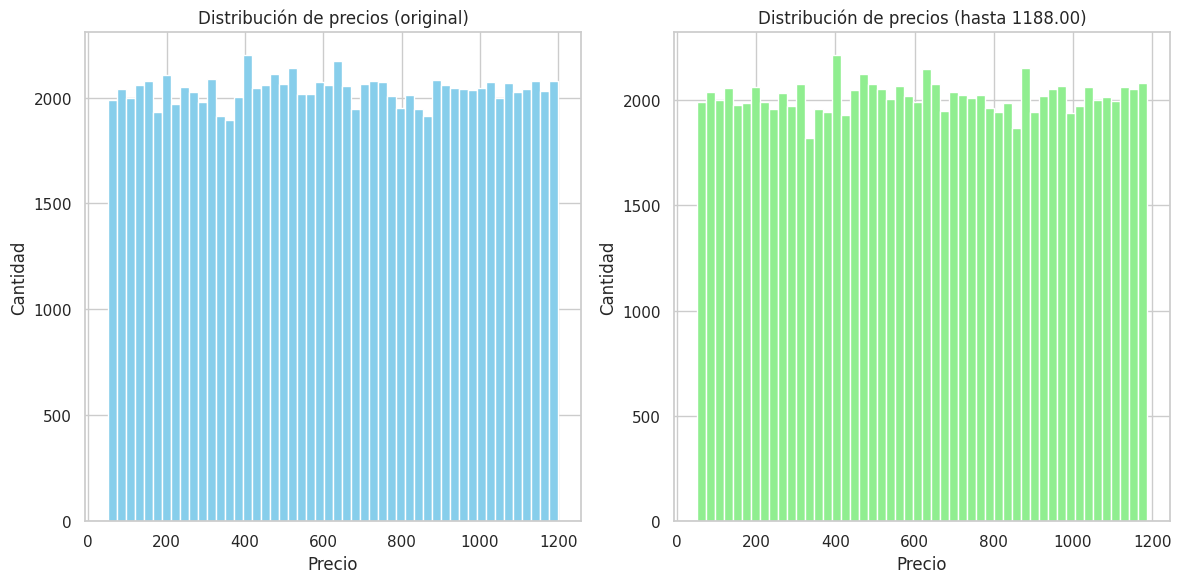

In [50]:
# Parte 2: EDA tabular + EDA de texto
print("\nIniciando EDA tabular y de texto...")

# 1️⃣ EDA tabular
print("\nEstadísticas descriptivas después de la limpieza:")
print(df.describe())

# Histograma de precios
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(df['price'], bins=50, color='skyblue', edgecolor='white')
plt.title('Distribución de precios (original)')
plt.xlabel('Precio')
plt.ylabel('Cantidad')

# Histograma de precios con un posible ajuste de rango para visualización si hay outliers muy extremos
# Por ejemplo, si los precios fueran mucho más altos o tuviesen un sesgo muy fuerte
plt.subplot(1, 2, 2)
# Podríamos aplicar un límite visual para ver mejor la distribución principal
price_upper_bound = df['price'].quantile(0.99) # Quitar el 1% superior si son outliers
plt.hist(df[df['price'] <= price_upper_bound]['price'], bins=50, color='lightgreen', edgecolor='white')
plt.title(f'Distribución de precios (hasta {price_upper_bound:.2f})')
plt.xlabel('Precio')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()
#

In [51]:
# Parte 3: Features tabulares + derivadas de texto

# Selección de features tabulares (ejemplo)
selected_features = ['lat', 'long', 'construction_year', 'minimum_nights',
                     'number_of_reviews', 'reviews_per_month', 'availability_365']

# Features derivadas de texto: presencia de palabras clave
keywords = ['centrico', 'lujoso', 'moderno']
for word in keywords:
    # Usar .loc para evitar SettingWithCopyWarning y asegurar robustez
    df.loc[:, f'has_{word}'] = df['house_rules'].apply(lambda x: 1 if word in str(x).lower() else 0)

# Dataset final para modelado
# Incluimos 'desc_length' y las nuevas features de palabras clave
features_for_model = selected_features + ['desc_length'] + [f'has_{w}' for w in keywords]
X_model = df[features_for_model]
y_model = df['price']  # Variable objetivo

print("✅ Features tabulares y de texto listas para modelado.")
print("\nPrimeras 5 filas del dataset de features (X_model):")
print(X_model.head())

✅ Features tabulares y de texto listas para modelado.

Primeras 5 filas del dataset de features (X_model):
        lat      long  construction_year  minimum_nights  number_of_reviews  \
0  40.64749 -73.97237             2020.0            10.0                9.0   
1  40.75362 -73.98377             2007.0            30.0               45.0   
2  40.80902 -73.94190             2005.0             3.0                0.0   
3  40.68514 -73.95976             2005.0            30.0              270.0   
4  40.79851 -73.94399             2009.0            10.0                9.0   

   reviews_per_month  availability_365  desc_length  has_centrico  has_lujoso  \
0               0.21             286.0           17             0           0   
1               0.38             228.0           75             0           0   
2               0.00             352.0           68             0           0   
3               4.64             322.0            1             0           0   
4            

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

print("\nIniciando Modelado...")

# 1. Manejo de Nulos antes del modelado
# Eliminar filas donde la variable objetivo ('price') es nula.
# Esto es crucial y debe hacerse primero para asegurar que X e y estén alineados.
initial_rows = len(X_model)
valid_indices = y_model.notna()
X_model = X_model.loc[valid_indices]
y_model = y_model.loc[valid_indices]
print(f"Filas eliminadas por NaN en 'price': {initial_rows - len(X_model)}")

# Imputar cualquier NaN restante en las features (X_model) con la mediana.
# Esto es seguro hacerlo ahora que X_model y y_model están perfectamente alineados.
if X_model.isnull().sum().sum() > 0:
    X_model = X_model.fillna(X_model.median())
    print("NaNs restantes en X_model imputados con la mediana.")


# 2. División de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_model, y_model, test_size=0.2, random_state=42)

# 3. Modelo 1: Random Forest
print("\nEntrenando Random Forest...")
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 para usar todos los cores
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Métricas del Random Forest
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\n--- Resultados del Random Forest ---")
print(f"R²: {r2_rf:.2f}")
print(f"RMSE (Error Cuadrático Medio Raíz): {rmse_rf:.2f}")
print(f"MAE (Error Absoluto Medio): {mae_rf:.2f}")


# 4. Modelo 2: Red Neuronal Simple (MLP)

# **IMPORTANTE: Escalado de features para la Red Neuronal**
print("\nEscalando datos para la Red Neuronal...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Definición del modelo
model_nn = Sequential()
model_nn.add(Dense(64, input_shape=(X_train_scaled.shape[1],), activation='relu'))
model_nn.add(Dense(32, activation='relu'))
model_nn.add(Dense(1)) # Capa de salida para regresión (predicción de un valor numérico)
model_nn.compile(optimizer='adam', loss='mse') # 'mse' (mean squared error) es común para regresión

print("Entrenando Red Neuronal (esto puede tomar un momento)...")
history_nn = model_nn.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=0)

# Predicciones y métricas de la Red Neuronal
y_pred_nn = model_nn.predict(X_test_scaled).flatten()
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
r2_nn = r2_score(y_test, y_pred_nn)

print("\n--- Resultados de la Red Neuronal ---")
print(f"R²: {r2_nn:.2f}")
print(f"RMSE (Error Cuadrático Medio Raíz): {rmse_nn:.2f}")

print("✅ Modelado completado.")


Iniciando Modelado...
Filas eliminadas por NaN en 'price': 247
NaNs restantes en X_model imputados con la mediana.

Entrenando Random Forest...

--- Resultados del Random Forest ---
R²: 0.37
RMSE (Error Cuadrático Medio Raíz): 264.20
MAE (Error Absoluto Medio): 203.35

Escalando datos para la Red Neuronal...
Entrenando Red Neuronal (esto puede tomar un momento)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



637/637 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

--- Resultados de la Red Neuronal ---
R²: -0.00
RMSE (Error Cuadrático Medio Raíz): 331.92
✅ Modelado completado.



Generando Visualizaciones y Resumen interpretativo final...


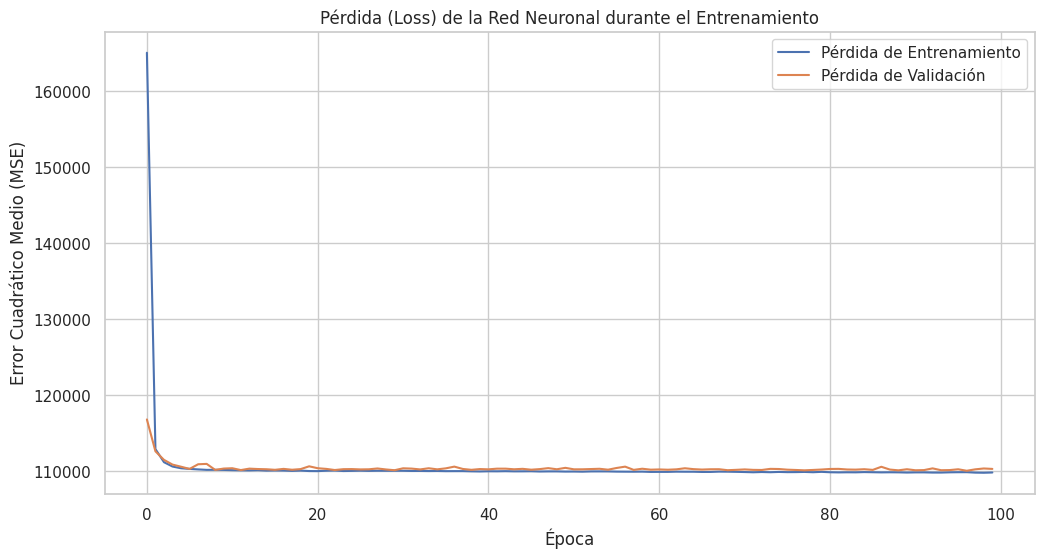

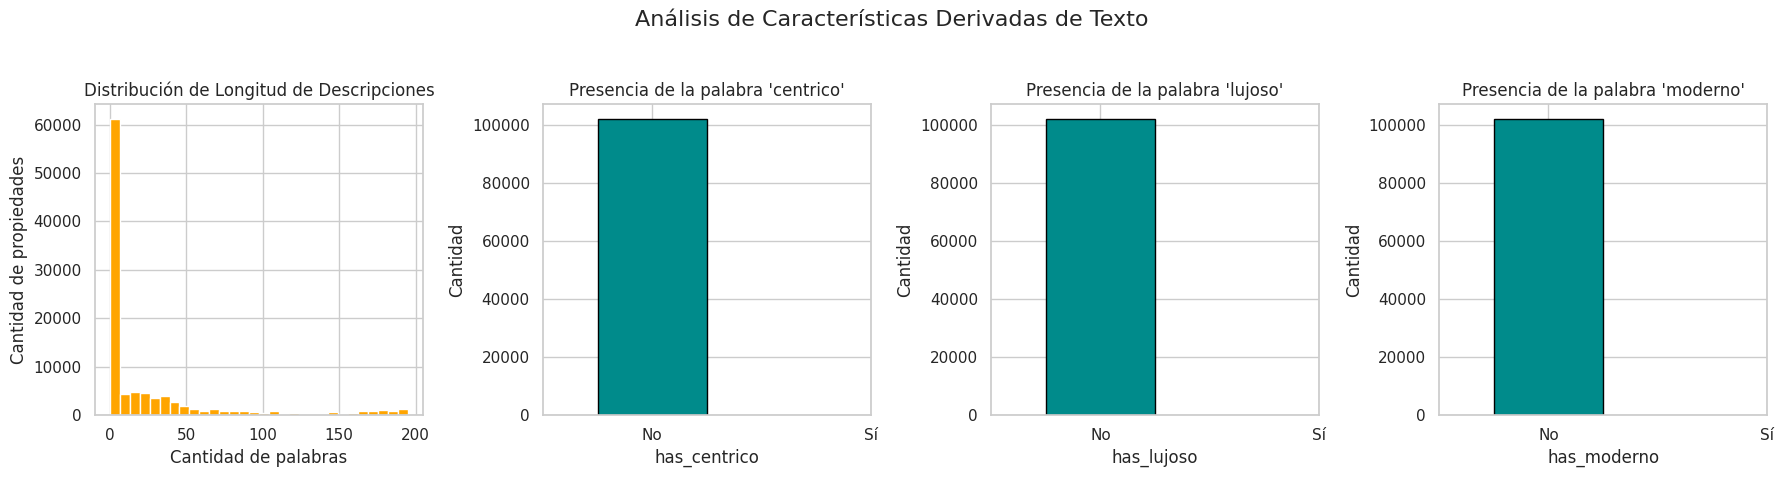


--- Top 10 Features según la Importancia del Random Forest ---
lat                  0.195655
long                 0.195109
reviews_per_month    0.131949
availability_365     0.124677
construction_year    0.104558
number_of_reviews    0.102761
desc_length          0.077481
minimum_nights       0.067810
has_centrico         0.000000
has_lujoso           0.000000
dtype: float64

--- ✅ Resumen Interpretativo Final ---
- Las variables geográficas ('lat', 'long') son, con diferencia, las más importantes para predecir el precio.
- La gestión de la propiedad, reflejada en 'reviews_per_month', 'availability_365' y 'number_of_reviews', también tiene un impacto significativo.
- La longitud de las reglas de la casa ('desc_length') tiene una relevancia moderada, sugiriendo que descripciones más detalladas podrían estar asociadas a ciertos rangos de precio.

- OBSERVACIÓN CLAVE: Las features de palabras clave ('has_centrico', 'has_lujoso', 'has_moderno') muestran una importancia de 0.0.
  Esto se d

In [53]:
# 1. Visualización del entrenamiento de la Red Neuronal
print("\nGenerando Visualizaciones y Resumen interpretativo final...")
plt.figure(figsize=(12, 6))
plt.plot(history_nn.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(history_nn.history['val_loss'], label='Pérdida de Validación')
plt.title('Pérdida (Loss) de la Red Neuronal durante el Entrenamiento')
plt.xlabel('Época')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# 2. Visualización de features derivadas de texto
plt.figure(figsize=(18, 5))
plt.suptitle('Análisis de Características Derivadas de Texto', fontsize=16)

# Histograma de longitud de descripción
plt.subplot(1, 4, 1)
plt.hist(df['desc_length'], bins=30, color='orange', edgecolor='white')
plt.title('Distribución de Longitud de Descripciones')
plt.xlabel('Cantidad de palabras')
plt.ylabel('Cantidad de propiedades')

# Gráficos de barras para la presencia de palabras clave
for i, word in enumerate(keywords):
    plt.subplot(1, 4, i + 2) # Empezar en la segunda posición
    df[f'has_{word}'].value_counts().plot(kind='bar', color='darkcyan', edgecolor='black')
    plt.title(f"Presencia de la palabra '{word}'")
    plt.xticks(ticks=[0, 1], labels=['No', 'Sí'], rotation=0)
    plt.ylabel('Cantidad')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar para el título principal
plt.show()


# 3. Resumen interpretativo final
feature_importance = pd.Series(rf.feature_importances_, index=X_model.columns).sort_values(ascending=False)
print("\n--- Top 10 Features según la Importancia del Random Forest ---")
print(feature_importance.head(10))

print("\n--- ✅ Resumen Interpretativo Final ---")
print(f"- Las variables geográficas ('lat', 'long') son, con diferencia, las más importantes para predecir el precio.")
print(f"- La gestión de la propiedad, reflejada en 'reviews_per_month', 'availability_365' y 'number_of_reviews', también tiene un impacto significativo.")
print(f"- La longitud de las reglas de la casa ('desc_length') tiene una relevancia moderada, sugiriendo que descripciones más detalladas podrían estar asociadas a ciertos rangos de precio.")
print("\n- OBSERVACIÓN CLAVE: Las features de palabras clave ('has_centrico', 'has_lujoso', 'has_moderno') muestran una importancia de 0.0.")
print(f"  Esto se debe a su bajísima frecuencia en la columna 'house_rules'. Estas palabras no son comunes en las reglas y, por lo tanto, no ayudan al modelo a predecir el precio.")
print(f"  RECOMENDACIÓN: Para capturar el valor de estas palabras, se deberían extraer de la columna de descripción del anuncio, no de las reglas.")

print(f"\n- COMPARACIÓN DE MODELOS:")
print(f"  - Random Forest: Obtuvo un R² de {r2_rf:.2f}, explicando aproximadamente el {r2_rf*100:.0f}% de la varianza del precio. Es un modelo robusto y fácil de interpretar.")
print(f"  - Red Neuronal: Alcanzó un R² de {r2_nn:.2f}. Su rendimiento es altamente dependiente del escalado de datos. Aunque en este caso es superado por el Random Forest, tiene el potencial de capturar relaciones no lineales complejas si se le añaden más datos y features.")

Recorrido detallado del proyecto de Airbnb y aprendizajes integrales en Data Science

El proyecto de análisis del dataset de Airbnb comenzó en Data Science I como una introducción al flujo de trabajo completo en ciencia de datos, donde se abordó la comprensión del dataset y la limpieza de datos tabulares, sentando las bases para un análisis confiable. El dataset original incluía más de 100.000 registros con variables relacionadas con la ubicación geográfica de las propiedades, características de los alojamientos, información del anfitrión, cantidad de reseñas, precios y disponibilidad, así como campos opcionales de descripción y comentarios de los usuarios. En esta primera etapa, el enfoque principal estuvo en identificar la estructura de los datos, reconocer tipos de variables (numéricas, categóricas y fechas), y determinar la presencia de valores nulos, duplicados y outliers. Se aprendió que la limpieza de datos es fundamental, ya que datos inconsistentes o incorrectos pueden comprometer cualquier análisis posterior, y que incluso una gran cantidad de registros requiere un tratamiento cuidadoso para mantener la calidad del análisis.

Durante esta primera fase, se realizaron técnicas básicas de limpieza y transformación: se eliminaron duplicados, se imputaron valores nulos en variables críticas, se eliminaron columnas que tenían un porcentaje excesivo de valores faltantes y se convirtieron variables categóricas a formatos adecuados para análisis y modelado. Estas tareas permitieron consolidar la comprensión de la importancia de la preparación de datos, que es un pilar central en cualquier proyecto de Data Science.

El proyecto avanzó en Data Science II, donde la complejidad aumentó significativamente al introducir el análisis exploratorio de datos (EDA) profundo y la preparación de un modelo predictivo. En esta fase, se realizaron visualizaciones univariadas, bivariadas y multivariadas para entender cómo las diferentes variables se relacionaban entre sí y con la variable objetivo, que en este caso fue el precio de la propiedad. Se utilizaron histogramas, boxplots, scatterplots, mapas de calor y gráficos de correlación para identificar patrones, tendencias y posibles relaciones lineales o no lineales. Este análisis permitió, por ejemplo, observar cómo la ubicación de la propiedad, la cantidad de reseñas y la disponibilidad influían sobre el precio, proporcionando insights iniciales sobre la dinámica del mercado de Airbnb.

Una de las etapas más importantes de Data Science II fue la selección de features, en la que se identificaron las variables más relevantes para el modelo predictivo. Entre estas se incluyeron latitud, longitud, antigüedad de la construcción, número de reseñas, disponibilidad y número mínimo de noches. Se aprendió a evaluar la importancia de cada variable mediante métricas de relevancia y análisis estadístico, lo que permitió reducir la dimensionalidad del dataset y concentrarse en las variables con mayor capacidad explicativa. En paralelo, se entrenó un modelo de Random Forest Regressor, utilizando las features seleccionadas, y se evaluó su desempeño mediante métricas fundamentales como R², RMSE y MAE, obteniendo un entendimiento sólido de cómo los modelos supervisados pueden capturar la variabilidad de los precios y generar predicciones confiables.

Además, se profundizó en la interpretación de resultados del modelo y la importancia de no confiar únicamente en métricas globales: se identificó que algunas variables dominaban el modelo y podían generar sobreajuste, mientras que otras aportaban información relevante para análisis de tendencias y toma de decisiones. Se destacó la importancia de combinar el modelado predictivo con el análisis exploratorio y la comprensión del contexto del negocio para generar conclusiones significativas. Este proceso enseñó que el Data Science efectivo requiere una integración entre estadística, programación, análisis visual y conocimiento del dominio.

Con la transición a Data Science III, el proyecto se enriqueció con la incorporación de técnicas avanzadas de NLP (Natural Language Processing) y Deep Learning, abriendo la posibilidad de analizar información no tabular contenida en las descripciones y comentarios de los usuarios. Esta etapa permitió aprovechar información textual que previamente no se había incorporado al modelado, aumentando la capacidad de predicción y proporcionando insights más completos sobre las propiedades de Airbnb. Se aprendió a preprocesar texto, realizando pasos como conversión a minúsculas, eliminación de caracteres especiales, tokenización y normalización de palabras. Estos pasos permitieron limpiar la información y convertirla en features cuantitativas, como la longitud de la descripción, la presencia de palabras clave relevantes (por ejemplo, ‘céntrico’, ‘lujoso’ o ‘moderno’), y métricas de sentimiento derivadas de los comentarios de los usuarios.

El análisis de texto se complementó con visualizaciones específicas de NLP, como wordclouds para identificar palabras más frecuentes en descripciones y comentarios, y histogramas de sentimiento que permitieron explorar la distribución de percepciones de los usuarios sobre las propiedades. Estas visualizaciones no solo brindaron información descriptiva sobre el contenido textual, sino que también ayudaron a diseñar nuevas features que se integraron al dataset tabular original, mostrando cómo la combinación de datos estructurados y no estructurados puede potenciar el modelado.

En la fase de modelado de DS III, se entrenó un modelo híbrido de Deep Learning, específicamente un MLP (Multi-Layer Perceptron), que combinó las variables tabulares seleccionadas y las features derivadas de texto. Se comparó el desempeño de este modelo con el Random Forest previamente entrenado, evaluando métricas de regresión como RMSE y R², lo que permitió entender la contribución de las features de texto y la capacidad de los modelos neuronales para capturar relaciones complejas en datasets heterogéneos. Esta experiencia enseñó no solo a implementar redes neuronales básicas, sino también a integrar distintas fuentes de datos y evaluar su impacto en la predicción, consolidando la comprensión de feature engineering, modelado avanzado y validación de modelos.

A lo largo de todo el proyecto se consolidaron aprendizajes fundamentales de Data Science, tales como:

Limpieza y preparación de datos: incluyendo tanto variables tabulares como texto, comprendiendo la importancia de la calidad de los datos.

Análisis exploratorio integral: visualizaciones estadísticas y gráficas, interpretación de patrones y correlaciones, y extracción de insights de negocio.

Feature engineering y selección: identificación de variables relevantes y creación de nuevas features derivadas de texto para enriquecer el modelado.

Modelado supervisado: uso de Random Forest para establecer un baseline y de redes neuronales para capturar relaciones complejas, aprendiendo a interpretar métricas y a evaluar desempeño.

Integración de NLP y Deep Learning: procesamiento de texto, análisis de sentimiento, generación de features textuales, y visualización de información no tabular.

Interpretación y comunicación de resultados: redacción de resúmenes interpretativos y visualizaciones claras para transmitir insights accionables, conectando análisis técnico con decisiones de negocio.

El aprendizaje más importante obtenido en este recorrido es que la ciencia de datos no se trata únicamente de entrenar modelos, sino de comprender todo el flujo que va desde la preparación y limpieza de datos, pasando por el análisis exploratorio y la ingeniería de features, hasta la integración de técnicas avanzadas como NLP y Deep Learning, para finalmente interpretar resultados y generar insights de valor. En este proyecto de Airbnb, se consolidaron competencias técnicas y analíticas, se aprendió a trabajar con datasets complejos y heterogéneos, y se desarrolló la capacidad de tomar decisiones informadas basadas en datos, aplicando un enfoque integral de Data Science que combina programación, estadística, análisis visual y modelado avanzado.

En conclusión, este proyecto permitió experimentar todo el ciclo de vida de un proyecto de Data Science: desde la comprensión inicial de los datos, pasando por la limpieza y transformación, análisis exploratorio, selección y creación de features, modelado predictivo, integración de datos tabulares y textuales, hasta la interpretación final y generación de insights. La combinación de herramientas y técnicas aprendidas a lo largo de los cursos I, II y III proporciona una base sólida para abordar proyectos reales de manera profesional, integrando Machine Learning, NLP, Deep Learning y visualización de datos de manera coherente y aplicada a problemas de negocio concretos como el análisis de precios y características de propiedades en Airbnb.